# 서울시 상권 폐업위험 예측 모델

> **핵심 질문** — 다음 분기에 점포 순감소(폐업 > 개업)로 전환될 상권 × 업종은 어디이며, 무엇이 위험을 만드는가

요식업 10종 · 서울시 전체 상권 4유형 · 2023Q1~2025Q4 · 67,475칸 · 순감소 25.5%

본 문서는 분석 코드를 제외하고 출력물과 판단만 담음. 데이터 준비·EDA·모델링 전 과정의 결과를 한 편으로 합친 판본임.


## 한 장 요약

| 절 | 제목 | 핵심 한 줄 |
|---|---|---|
| 01 | 분석 개요 | 다음 분기에 폐업 수가 개업 수보다 많아질 ‘상권×업종’을 한 분기 먼저 찾고, 그 위험이 어디에서 오는지 설명하는 것이 목표임. |
| 02 | 데이터와 전처리 판단 | 결측을 무조건 지우지 않고, 왜 비어 있는지부터 판단했음. 특히 매출 결측은 영세 상권의 특성을 담을 수 있어 그대로 정보로 남겼음. |
| 03 | 라벨의 구조 — y=0에 섞여 있는 두 상태 | 순감소가 아닌 y=0에는 “성장·유지”뿐 아니라 “아무 변화가 없었던 곳”도 많이 섞여 있음. 이 때문에 단순 모델은 위험보다 상권 규모를 먼저 배울 수 있음. |
| 04 | 기초 탐색과 상권유형별 차이 | 상권유형별 순감소율 차이는 통계적으로는 분명했지만, 실제 차이의 크기는 작았음. “유형 자체가 위험을 만듦”고 바로 결론낼 정도는 아니었음. |
| 05 | 비교 기준 — 모델이 넘어야 하는 선 | 예측모델은 무작위보다만 좋아서는 부족함. 점포 수 하나만으로도 상당히 맞힐 수 있기 때문에, 실제 기준선은 “점포 수 규칙”임. |
| 06 | 점포 수를 고정하면 무엇이 남는가 | 점포 수가 비슷한 상권끼리 비교하면 유형별 결론이 뒤집힌다 — 골목상권은 안전에서 위험으로, 발달상권은 위험에서 차이 없음으로. 규모가 상권유형과 위험 사이를 교란하고 있었음. |
| 07 | 검정 방법의 선택 — 정규성과 등분산성 | 데이터 분포가 정규분포와 거리가 있고 일부 집단은 분산도 달랐기 때문에, 평균 비교보다 순위 기반의 Kruskal-Wallis 검정을 주 검정으로 사용했음. |
| 08 | 가설 직접 검증 — 업종 × 상권유형 · 업종 × 자치구 | 같은 업종이라도 상권유형에 따라 위험이 달라지지만, 효과크기 기준으로 보면 실질적 차이가 있는 업종은 세 개뿐임. |
| 09 | 성향점수매칭 — 조건을 맞추고 다시 비교 | 한식음식점은 단순 비교에서는 더 위험해 보였지만, 규모와 입지가 비슷한 곳끼리 짝지으니 오히려 순감소 위험이 낮았음. |
| 10 | 사후검정 — 어느 상권유형이 실제로 다른가 | 전체적으로 차이가 있다는 것만으로는 부족해, Dunn 사후검정으로 상권유형을 두 개씩 비교했음. 전통시장과 골목상권만 뚜렷하게 구분되지 않았음. |
| 11 | 모델 선정 | 다섯 모델의 AP가 0.398~0.408에 몰려 있었고, 그 안에서 검증 AP가 가장 높은 랜덤포레스트를 대표 모델로 채택했음. |
| 12 | 선정 규모 — 몇 곳을 위험 대상으로 볼 것인가 | 모델은 많은 곳을 넓게 잡을 때보다, 실제 담당자가 볼 수 있는 상위 수십~수백 곳을 우선 선별할 때 가장 유용했음. |
| 13 | 테스트 최종 평가 — 2026년 1분기 결과 | 학습과 모델 선택에 쓰지 않은 홀드아웃 분기에서 **AP 0.413, Lift(향상도) 1.627**을 기록했음. 전체 순위 성능은 점포 수 기준과 비슷했지만, 상위 소수 구간에서는 모델이 더 높았음. |
| 14 | 예측 결과와 오차 — 무엇을 맞히고 무엇을 틀렸는가 | 「다음 분기에 줄어들 상권을 다 찾아내는 모델」로는 성립하지 않고, 「먼저 볼 50~300곳을 골라주는 도구」로는 성립한다. 맞힌 것과 틀린 것이 규모에 따라 갈리고, 놓친 위험은 작고 조용한 칸에 몰린다. |
| 15 | 두 단계로 나눈 모형 | 순감소를 “① 다음 분기에 개·폐업이 일어나는가”와 “② 일어났다면 감소 방향인가”로 나누자, 상권 규모 효과가 대부분 1단계에 모여 있음을 확인했음. |
| 16 | 두 확률로 나눈 상권 유형 | 최종 위험점수 하나로만 줄 세우지 않고 “변화가 자주 생기는가”와 “변하면 감소하는가”를 두 축으로 남기면 성격이 다른 네 유형을 구분할 수 있음. |
| 17 | 무엇이 위험과 관련되어 있는가 | 단일 모델에서는 규모·밀도 변수가 기여도의 3분의 2를 차지했지만, 사건과 방향을 분리하자 규모 영향은 주로 1단계에 남고 2단계에서는 4분의 1로 줄었음. |
| 18 | 위험도 공간 분석 | 지도에서는 위험등급이 높아질수록 실제 순감소율도 **13.4% → 42.1%**로 증가했음. 다만 자치구 경계나 역과의 거리 자체는 위험을 잘 설명하지 못했음. |
| 19 | 종합 결론 | 다음 분기 순감소를 완벽하게 예측한 것은 아니지만, 상위 소수 고위험 상권을 한 분기 먼저 선별하고 규모에 가려진 위험 구조를 분리해 설명할 수 있었음. |
| 20 | 비즈니스 제언 | 지원 대상은 업종이 아니라 상권 단위로, 그것도 「두 축」으로 골라야 함. 규모를 통제하지 않은 목록은 방향이 반대로 나옴. |


## 01  분석 개요

**핵심 한 줄 — 다음 분기에 폐업 수가 개업 수보다 많아질 ‘상권×업종’을 한 분기 먼저 찾고, 그 위험이 어디에서 오는지 설명하는 것이 목표임.**

### 왜 이 분석을 했나

연구 질문과 분석 단위를 먼저 고정해, 뒤의 통계검정과 예측모델이 같은 대상을 보고 있는지 명확히 했음.

### 핵심 결과

- 분석 단위는 상권 × 요식업 업종 × 분기임. 업종은 한식·중식·일식·양식·제과·패스트푸드·치킨·분식·호프·커피 등 10종임.
- 기간은 2023년 1분기~2025년 4분기이며, 2026년 1분기는 2025년 4분기의 “다음 분기 결과”를 만들기 위해서만 사용했음.
- 라벨은 “다음 분기에 폐업 수 > 개업 수인가”임. 매출 감소가 아니라 실제 점포 수의 순감소를 직접 잡기 위한 선택임.



| 항목 | 핵심 수치 / 의미 |
|---|---|
| 최종 표본 | 점포 5개 이상인 상권×업종×분기 67,475건 |
| 순감소 비율 | 25.5% |
| 예측 목표 | 다음 분기의 순감소 여부 |
| 핵심 산출물 | 위험순위 + 위험요인 + 상권 유형화 |

*표 1*


### 해석

따라서 이 보고서의 “폐업위험”은 개별 가게의 폐업확률이 아니라, 특정 상권의 특정 업종에서 다음 분기에 점포 수가 순감소할 가능성을 뜻함.



## 02  데이터와 전처리 판단

**핵심 한 줄 — 결측을 무조건 지우지 않고, 왜 비어 있는지부터 판단했음. 특히 매출 결측은 영세 상권의 특성을 담을 수 있어 그대로 정보로 남겼음.**

### 왜 이 분석을 했나

잘못된 결측 처리나 중복 변수를 넣으면 표본이 줄거나 같은 정보를 여러 번 세어 모델 해석이 왜곡될 수 있음.

### 핵심 결과

- 원천은 서울시 우리마을가게 상권분석서비스임. 매출은 카드 결제 기반 추정치, 유동인구는 생활인구, 점포는 사업자등록 자료를 사용함.
- “폐업”은 실제 문을 닫은 날짜가 아니라 사업자등록 말소 시점임. 따라서 실제 폐점 시점과 시차가 있을 수 있음.
- 집객시설의 빈칸은 시설이 없음을 뜻하는 자료 구조로 판단해 0으로 처리했음.
- 유동인구가 상주·직장 인구 정보를 이미 포함하므로 인구 변수를 중복해서 넣지 않았음. 직장인구 비중은 단독 판별력이 낮아(AUC 0.520) 제외했음.



| 항목 | 핵심 수치 / 의미 |
|---|---|
| 매출 결측률 | 45.4% |
| 매출 결측 처리 | 행 삭제 대신 “매출이 관측되지 않음” 자체를 정보로 유지 |
| 기타 핵심 변수 | 면적·유동인구·점포 수·상권변화지표·운영개월 등은 결측이 거의 없음 |

*표 2*


|  | 컬럼 | 결측률 | 판정 |
|---|---|---|---|
| 0 | 엑스좌표_값 | 0.0% | OK |
| 1 | 영역_면적 | 0.0% | OK |
| 2 | 총_유동인구_수 | 0.0% | OK |
| 3 | 역세권 | 2.3% | OK |
| 4 | 상권_변화_지표 | 0.0% | OK |
| 5 | 당월_매출_금액 | 45.4% | 공변량 제외 권장 |
| 6 | 상권_전체점포 | 0.0% | OK |
| 7 | 운영_영업_개월_평균 | 0.0% | OK |
| 8 | 운영개월_서울대비 | 0.0% | OK |
| 9 | 외식물가지수 | 0.0% | OK |
| 10 | 외식지출전망 | 0.0% | OK |

*표 3*

읽는 법 — 결측률 5% 이하는 그대로 쓰고 30%를 넘으면 공변량에서 빼는 기준으로 「판정」 열을 붙였음. 매출 계열만 주의 구간에 들어감.

기준 — 결측률 5% 이하는 그대로 사용 · 5~30% 주의 · 30% 초과는 공변량에서 제외 검토. 관례적 눈금이며 이 표에서 제외 대상은 없음.


### 해석

핵심은 “결측=오류”로 단정하지 않은 것임. 카드 결제가 충분히 잡히지 않는 소규모 상권이라는 특성이 결측에 들어 있을 수 있으므로, 결측 행을 통째로 버리면 오히려 작은 상권을 체계적으로 잃게 됨.



## 03  라벨의 구조 — y=0에 섞여 있는 두 상태

**핵심 한 줄 — 순감소가 아닌 y=0에는 “성장·유지”뿐 아니라 “아무 변화가 없었던 곳”도 많이 섞여 있음. 이 때문에 단순 모델은 위험보다 상권 규모를 먼저 배울 수 있음.**

### 왜 이 분석을 했나

작은 상권은 안전해서가 아니라 점포 수가 적어서 한 분기 동안 개업·폐업이 아예 관측되지 않을 가능성이 높음.

### 핵심 결과

- 전체의 43.9%는 다음 분기에 개업도 폐업도 없는 “변화 없음”이었음.
- y=0인 50,285건 중 58.9%가 “변화 없음”이었음. 즉 y=0을 곧바로 “안전”이라고 해석하면 안 됨.
- 점포 수가 가장 적은 구간에서는 변화 없음이 69.3%였지만, 가장 큰 구간에서는 7.9%까지 떨어졌음. 같은 방향으로 순감소율은 15.1%에서 40.3%로 올라갔음.



| 항목 | 핵심 수치 / 의미 |
|---|---|
| 변화 없음 | 29,633건 · 43.9% |
| 변화는 있었지만 순감소 아님 | 20,652건 · 30.6% |
| 순감소 | 17,190건 · 25.5% |
| 점포 규모 효과 | 평균 5.4개 구간: 변화 없음 69.3% → 평균 65.5개 구간: 7.9% |

*표 4*


|  | 건수 | 비율 |
|---|---|---|
| 변화 없음 | 29633 | 0.439 |
| 변화 있었으나 줄지 않음 | 20652 | 0.306 |
| 순감소 | 17190 | 0.255 |

*표 5*

읽는 법 — 다음 분기 상태를 셋으로 나눈 비율임. y=0 은 위 두 줄(변화 없음 + 줄지 않음)의 합임.

기준 — y=0 은 「변화 없음」과 「변화 있었으나 줄지 않음」의 합. 판정 기준이 아니라 라벨 구성의 분해임.


|  | 칸수 | 평균점포 | 변화없음비율 | 순감소율 |
|---|---|---|---|---|
| 1분위 | 15520 | 5.44 | 0.693 | 0.151 |
| 2분위 | 14018 | 7.86 | 0.599 | 0.193 |
| 3분위 | 12139 | 11.73 | 0.465 | 0.243 |
| 4분위 | 12718 | 19.56 | 0.298 | 0.308 |
| 5분위 | 13080 | 65.47 | 0.079 | 0.403 |

*표 6*

읽는 법 — 1분위가 점포가 가장 적은 구간임. 「변화없음비율」 열을 위에서 아래로 읽으면 규모가 커질 때 「아무 일도 없음」이 어떻게 줄어드는지 보임.

기준 — 규모가 커질 때 「변화없음비율」이 줄고 「순감소율」이 오르면 라벨이 규모에 끌려간다는 신호.


### 해석

따라서 아무 조정 없이 학습하면 모델은 “어떤 조건에서 쇠퇴하는가”보다 “어디에서 사건이 일어날 만큼 점포가 많은가”를 학습할 수 있음. 이후의 규모 통제와 2단계 모형은 이 문제를 해결하기 위한 장치임.



## 04  기초 탐색과 상권유형별 차이

**핵심 한 줄 — 상권유형별 순감소율 차이는 통계적으로는 분명했지만, 실제 차이의 크기는 작았음. “유형 자체가 위험을 만듦”고 바로 결론낼 정도는 아니었음.**

### 왜 이 분석을 했나

표본이 수만 건이면 아주 작은 차이도 p-value가 매우 작게 나옴. 그래서 “차이가 존재하는가”와 “차이가 큰가”를 함께 봐야 함.

### 핵심 결과

- 상권유형 × 순감소 카이제곱 검정은 유의했지만 Cramér’s V=0.071로 효과크기는 작았음.
- Kruskal-Wallis도 유의했지만 ε²=0.0050으로 실제 차이는 크지 않았음.
- 변수 간 상관은 일부 높았지만 |r|>0.8인 쌍은 없었음. 가장 큰 상관은 업종밀도와 업종점포비중(r=0.753)이었음.



| 항목 | 핵심 수치 / 의미 |
|---|---|
| 통계적 차이 | χ²(3)=337.9, p<0.001 |
| 효과크기 | Cramér’s V=0.071 · ε²=0.0050 → 작음 |
| 해석 주의 | 상권유형 안에 규모와 업종 구성이 섞여 있으므로 추가 통제가 필요 |

*표 7*

기준 — 효과크기 기준이 처음 나오는 자리임 — **Cramér's V 는 0.1 작음 / 0.3 중간 / 0.5 큼**(자유도 1 기준), **ε² 는 0.01 작음 / 0.06 중간 / 0.14 큼**임. 표본이 수만 건이면 p 는 거의 항상 유의하게 나오므로 이 절부터 판정은 효과크기로 함.


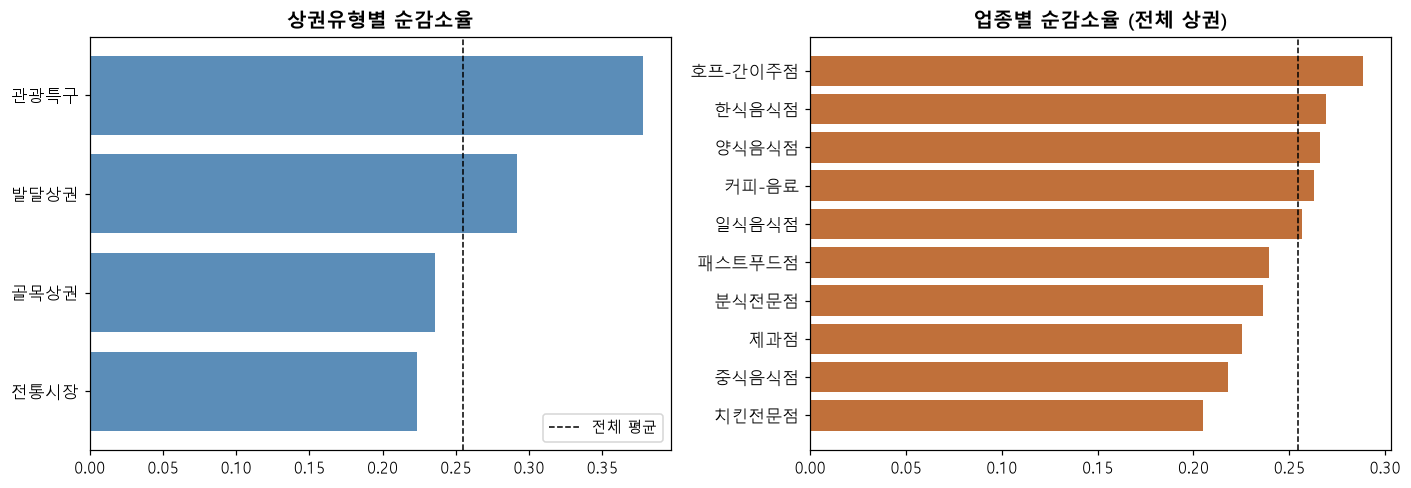

*그림 1*

읽는 법 — 왼쪽이 유형별, 오른쪽이 업종별 순감소율이고 점선이 전체 평균임.


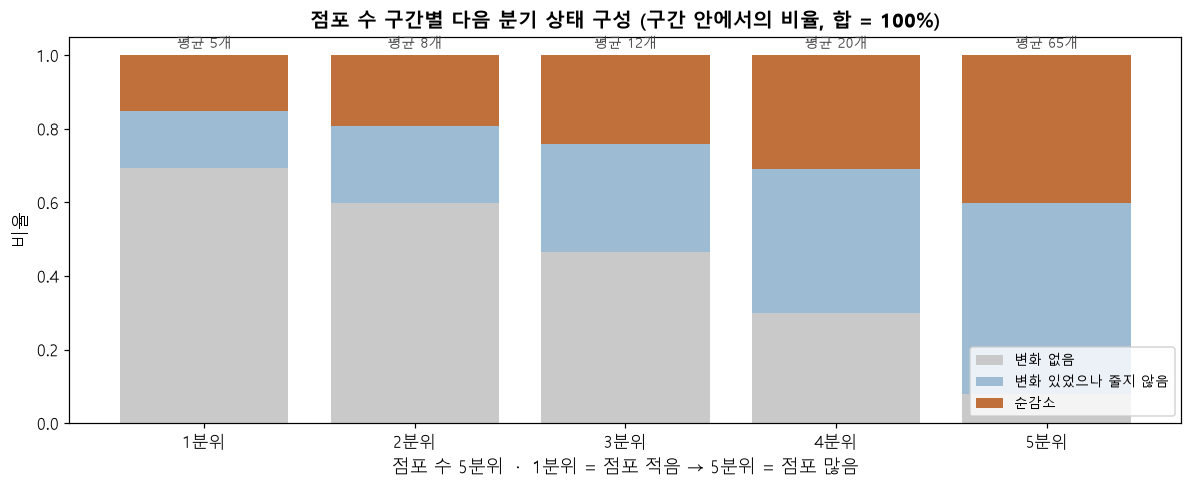

*그림 2*

읽는 법 — 구간 안에서의 비율이라 막대 하나의 합이 100%임. 회색이 「변화 없음」이고, 왼쪽으로 갈수록 회색이 커지는 것이 규모 편향의 통로임.


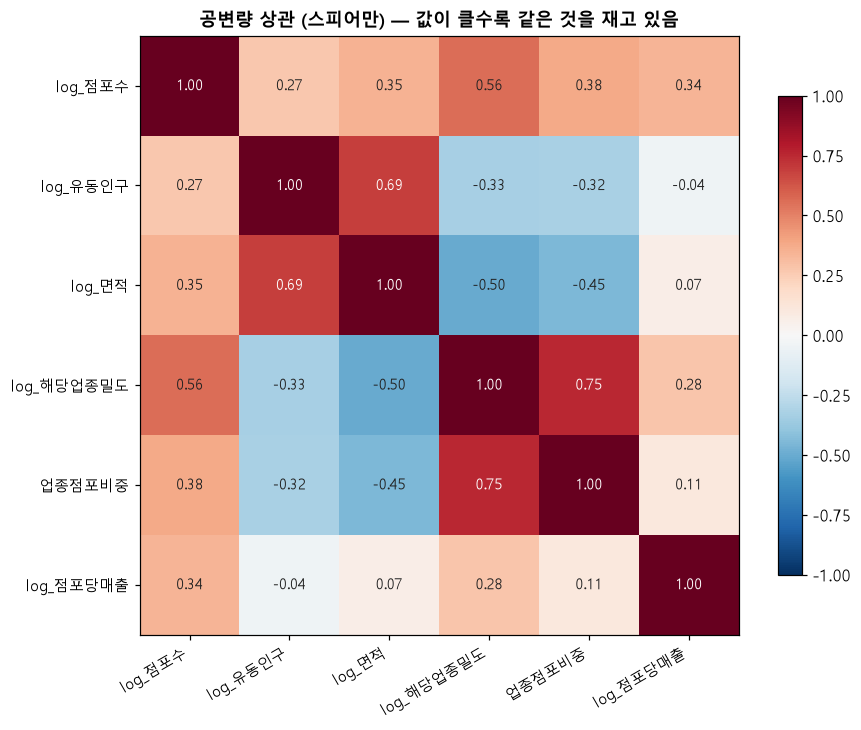

*그림 3*

읽는 법 — 공변량끼리 얼마나 「같은 것을 측정하고 있는가」임. 붉을수록 강한 양의 상관이고, 0.7 안팎으로 붙어 있는 「업종 밀도 ↔ 업종 점포 비중」과 「유동인구 ↔ 면적」은 각각 한 덩어리로 읽어야 함.


### 해석

이 단계의 결론은 “상권유형별 차이가 아예 없음”도, “상권유형이 원인임”도 아님. 차이는 보이지만 그 크기가 작으므로, 점포 수와 업종 구성을 분리한 뒤 다시 확인해야 함.



## 05  비교 기준 — 모델이 넘어야 하는 선

**핵심 한 줄 — 예측모델은 무작위보다만 좋아서는 부족함. 점포 수 하나만으로도 상당히 맞힐 수 있기 때문에, 실제 기준선은 “점포 수 규칙”임.**

### 왜 이 분석을 했나

큰 상권일수록 개업·폐업 사건이 더 자주 발생함. 이 규모 효과를 이기지 못하면 복잡한 모델을 쓸 이유가 없음.

### 핵심 결과

- 무작위로 고르면 정밀도는 전체 순감소율과 같은 25.5%임.
- 직전 분기 상태를 그대로 쓰면 정밀도 28.4%, Lift(향상도) 1.11로 개선 폭이 작았음.
- 서울시 상권변화지표(HL)는 정밀도 24.4%, Lift(향상도) 0.956으로 다음 분기 예측 목적에서는 무작위보다 낮았음.
- 점포 수가 많은 순으로 같은 수를 고르면 정밀도 39.4%, Lift(향상도) 1.54로 가장 강한 단순 기준이 됐음.



| 항목 | 핵심 수치 / 의미 |
|---|---|
| 무작위 | 정밀도 25.5% · Lift(향상도) 1.00 |
| 직전 분기 | 28.4% · 1.11 |
| 서울시 상권변화지표(HL) | 24.4% · 0.956 |
| 점포 수 | 39.4% · 1.54 |

*표 8*


|  | 기준선 | 위험으로 찍은 수 | 정밀도 | 재현율 | Lift |
|---|---|---|---|---|---|
| 0 | 무작위(전부 위험) | 67475 | 0.255 | 1 | 1 |
| 1 | 직전 분기 | 15682 | 0.284 | 0.259 | 1.11 |
| 2 | 상권변화지표(HL) | 12608 | 0.244 | 0.179 | 0.956 |
| 3 | 점포 수(상위 15,682칸) | 15682 | 0.394 | 0.359 | 1.54 |

*표 9*

읽는 법 — **기저율은 그 분기에 실제로 순감소한 칸의 비율**임 — 전체 표본 25.5%, 테스트 분기 26.0%. 아무 정보 없이 한 칸을 찍었을 때 맞을 확률이고, **Lift(향상도) = 정밀도 ÷ 기저율**이라 1.0 이 무작위임. 첫 줄 「무작위」는 67,475칸을 전부 찍는 설정이라 재현율이 정의상 1.0 이므로, 찍은 수가 다른 규칙끼리 재현율을 견주면 안 됨. 모델이 넘어야 하는 선은 이 표에서 가장 높은 값(점포 수)임.

기준 — 정밀도·재현율·Lift(향상도) 가 처음 나오는 자리임 — **정밀도는 위험으로 찍은 칸 중 실제 순감소였던 비율**, **재현율은 실제 순감소 칸 중 잡아낸 비율**이고 둘은 같은 작동점에서 맞바꾸는 값임. **Lift(향상도) = 정밀도 ÷ 기저율이라 1.0 이 무작위이고 1 미만은 무작위보다 못함.** 모델이 넘어야 하는 선은 이 표에서 가장 높은 값(점포 수 1.545).


### 해석

따라서 모델 성능을 “무작위보다 좋다”라고만 말하면 과장임. 이 연구에서 모델이 실제로 넘어야 할 비교선은 가장 강한 단순 규칙인 점포 수 기준임.



## 06  점포 수를 고정하면 무엇이 남는가

**핵심 한 줄 — 점포 수가 비슷한 상권끼리 비교하면 유형별 결론이 뒤집힌다 — 골목상권은 안전에서 위험으로, 발달상권은 위험에서 차이 없음으로. 규모가 상권유형과 위험 사이를 교란하고 있었음.**

### 왜 이 분석을 했나

전체를 한꺼번에 비교하면 골목상권이 상대적으로 작은 상권에 많이 있다는 사실과 순감소 위험이 섞임.

### 핵심 결과

- 점포 수 5분위 안에서 다시 비교하면 점포 수 규칙의 Lift(향상도)가 대부분 1에 가까워졌음. 전체에서 좋았던 성능의 상당 부분이 “큰 상권 고르기”였다는 뜻임.
- 규모를 통제하지 않은 단순 비교에서는 골목상권 OR=0.813로 더 안전해 보였음.
- 점포 수 구간을 통제한 CMH 검정에서는 공통 OR=1.061, p=0.0017로 방향이 반대로 바뀌었음.
- 다만 규모별 효과가 같지는 않았음. 작은·중간 구간 OR은 1.09~1.17이었지만 가장 큰 구간은 0.89였음. **같은 검정을 네 유형 각각에 돌리면 발달상권도 1.340 → 0.992로 뒤집힌다**(다만 p=0.689로 비유의). 전통시장만 층별 오즈비가 균일해(Woolf p=0.180) 하나의 값 0.896으로 요약할 수 있음.



| 항목 | 핵심 수치 / 의미 |
|---|---|
| 단순 비교 | 골목상권 OR 0.813 → 더 안전해 보임 |
| 규모 통제 후 | CMH 공통 OR 1.061 [1.023, 1.101] |
| 규모별 차이 | Woolf p=0.0000166 → 하나의 OR로 요약하기 어려움 |

*표 10*


|  | 칸수 | 평균점포 | 기저율 | 직전 분기 Lift | 상권변화지표 Lift | 점포 수 Lift | 점포 수 범위 |
|---|---|---|---|---|---|---|---|
| 1분위 | 15520 | 5.4 | 0.151 | 0.947 | 1.01 | **1.13** | 5 ~ 6개 |
| 2분위 | 14018 | 7.9 | 0.193 | 0.963 | 1.05 | **1.15** | 7 ~ 9개 |
| 3분위 | 12139 | 11.7 | 0.243 | 1 | 1.01 | **1.09** | 10 ~ 14개 |
| 4분위 | 12718 | 19.6 | 0.308 | 0.955 | 1.06 | **1.1** | 15 ~ 26개 |
| 5분위 | 13080 | 65.5 | 0.403 | 1.01 | 0.969 | **1.06** | 27개 이상 |
| **전체(층 무시)** | **67,475** | **21.4** | **0.255** | **1.11** | **0.956** | **1.545** | 5개 이상 전체 |

*표 11*

읽는 법 — 층 안에서 각 기준선을 다시 측정한 값임. 각 층에서 「직전 분기 순감소 칸수」만큼을 점포 수 많은 순으로 찍어 정밀도를 그 층의 기저율로 나눈 것임. **1분위 1.13 > 5분위 1.06 이 규모가 작은 쪽에서 점포 수가 더 유용하다는 뜻은 아님** — 층마다 기저율이 달라 Lift(향상도) 의 상한이 다르기 때문임(1분위는 최대 6.6배, 5분위는 2.5배). 또 5분위에서는 층의 40%를 찍게 되어 정밀도가 기저율에 수렴함. 읽어야 할 것은 층끼리의 비교가 아니라 **전체 표본에서 1.54 였던 값이 층 안에서 1.06~1.15 로 내려앉았다는 사실**임.

기준 — 층 안에서 Lift(향상도) 가 1 근처로 내려가면 그 규칙이 위험이 아니라 규모를 고르고 있었다는 뜻. 전체 표본 값과의 낙차가 「규모를 고른 몫」의 크기임.


**층(점포 수 5분위 · 괄호는 그 층의 점포 수 범위) × 네 상권유형 — 순감소율 % · 괄호는 그 유형의 칸수**

| 층 | 골목상권 | 발달상권 | 전통시장 | 관광특구 | 층 전체 |
|---|---|---|---|---|---|
| 1분위 (5~6개) | **15.8 (10,254)** | 12.8 (2,683) | 14.9 (2,577) | — (6) | 15,520 |
| 2분위 (7~9개) | **20.0 (8,518)** | 18.3 (3,368) | 18.3 (2,126) | — (6) | 14,018 |
| 3분위 (10~14개) | **25.2 (6,599)** | 23.5 (3,955) | 22.2 (1,578) | — (7) | 12,139 |
| 4분위 (15~26개) | **31.9 (5,667)** | 30.4 (5,405) | 29.1 (1,468) | 26.4 (178) | 12,718 |
| 5분위 (27개 이상) | 38.2 (3,609) | 42.0 (7,600) | 35.6 (1,372) | 42.1 (499) | 13,080 |
| 전체(층 무시) | **23.6 (34,647)** | **29.2 (23,011)** | 22.4 (9,121) | 37.8 (696) | 67,475 |

*표 12*

기준 — 판정 기준이 아니라 서술. 층을 무시한 순서와 층 안의 순서가 갈리는지를 보는 표임.


**네 유형 각각 「그 유형 대 나머지」 CMH**

| 상권유형 | 칸수 | 단순 오즈비 | MH 공통 오즈비 | 규모 통제 후 | 95% CI | CMH p | Woolf p |
|---|---|---|---|---|---|---|---|
| 골목상권 | 34,647 | 0.813 | **1.061** | ▲ +0.248 | [1.023, 1.101] | 0.0017 | 0.0000166 |
| 발달상권 | 23,011 | 1.340 | **0.992** | ▼ −0.348 | [0.954, 1.031] | 0.689 | 0.0000000187 |
| 전통시장 | 9,121 | 0.821 | **0.896** | ▲ +0.075 | [0.849, 0.945] | 0.00006 | **0.180** |
| 관광특구 | 696 | 1.789 | 1.023 | ▼ −0.766 | [0.873, 1.197] | 0.812 | 0.247 |

*표 13*

읽는 법 — **화살표 표기가 처음 나오는 자리임** — ▲ 는 값이 올라감, ▼ 는 내려감을 뜻하고 **색은 방향만 나타낼 뿐 좋고 나쁨과는 무관함.** 이 표에서는 ▲ 가 규모를 통제한 뒤 오즈비가 올라갔다는 뜻이므로 **위험이 커진 쪽**이고, 13절 「모델 − 점포 수」 열에서는 ▲ 가 모델이 기준선보다 높다는 뜻이라 **반대로 좋은 쪽**임. **표마다 무엇이 올라간 것인지 열 이름을 함께 읽어야 함.**

기준 — **오즈비는 1 이 「차이 없음」** — 95% CI 가 1 을 포함하지 않으면 유의. 크기 관행은 1.5 작음 / 2.5 중간 / 4.3 큼(확률로는 기저율 26% 기준 1.5 ≈ +8.5%p). **Woolf p ≥ 0.05 일 때만 공통 오즈비를 하나의 값으로 요약할 수 있음.**


### 해석

이 결과는 Simpson의 역설에 해당함. 실무적으로는 “골목상권이 더 위험하다/안전함”처럼 한 문장으로 묶기보다, 점포 규모를 나눠서 말해야 함.

**부호 반전은 골목상권과 발달상권 두 곳에서 나타나고, 두 유형은 서로 거울상이다** — 골목은 작은 층에서 불리(1.17)하고 큰 층에서 유리(0.886)한데 발달은 정확히 반대(0.793 → 1.187)다. **즉 남는 것은 유형 자체가 아니라 「규모 × 유형」의 상호작용**이며, 하나의 값으로 요약할 수 있는 유형은 전통시장뿐임.



## 07  검정 방법의 선택 — 정규성과 등분산성

**핵심 한 줄 — 데이터 분포가 정규분포와 거리가 있고 일부 집단은 분산도 달랐기 때문에, 평균 비교보다 순위 기반의 Kruskal-Wallis 검정을 주 검정으로 사용했음.**

### 왜 이 분석을 했나

검정 방법은 결과가 잘 나오는 것을 고르는 것이 아니라, 데이터가 어떤 분포를 가지는지 확인한 뒤 정해야 함.

### 핵심 결과

- 0/1 라벨 자체에 정규성 검정을 하는 대신, 각 상권×업종의 여러 분기 순감소 비율을 만들어 연속값으로 비교했음.
- 상권유형 4/4, 업종 10/10 그룹에서 정규성 검정이 기각됐음. 다만 이 변수는 1/12 단위의 이산량이므로, 이 결과는 참고로 두고 이산 데이터에 맞는 적합도 검정을 따로 했음.
- 등분산성도 상권유형과 업종 모두에서 위배됐다(Levene 중앙값 기준).
- 전체 분포는 왜도 +0.592로 오른쪽 꼬리가 길었고, 순감소가 한 번도 없었던 조합도 7.1% 있었음.



| 항목 | 핵심 수치 / 의미 |
|---|---|
| 정규성 | 상권유형 4/4 · 업종 10/10 위배 (참고값) |
| 등분산성 | 상권유형·업종 모두 위배 |
| 주 검정 | Kruskal-Wallis |
| 시각 확인 | Q-Q plot + Boxplot |

*표 14*


|  | 그룹 수 | 정규성 위배 | 정규성 성립 그룹 | Levene 통계량 | Levene p | 등분산성 |
|---|---|---|---|---|---|---|
| 상권유형 | 4 | 4/4 | 없음 | 16 | 2.3e-10 | 위배 |
| 서비스_업종_코드_명 | 10 | 10/10 | 없음 | 10.83 | 0 | 위배 |

*표 15*

읽는 법 — 그룹별 정규성 위배 개수와 등분산성(Levene) 결과임. 정규성 열은 관례상 남긴 참고값이고, **판정은 아래 적합도 검정으로 함** — 이 변수는 이산량이라 연속 분포를 전제하는 정규성 검정이 표본만 커지면 자동으로 기각되기 때문임.

기준 — **Levene p ≥ 0.05 면 등분산 성립.** 정규성 열은 관례상 남긴 참고값이고 판정은 아래 적합도 검정으로 함(이 변수는 이산량이라 연속 분포를 전제하는 검정이 표본만 커지면 기각됨).


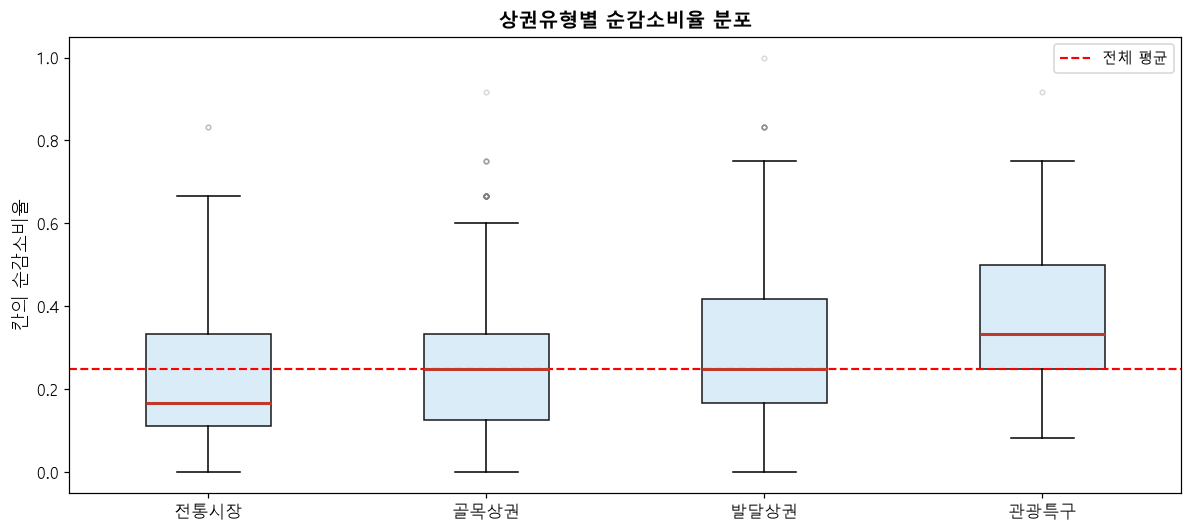

*그림 4*

읽는 법 — 상자 높이가 그룹마다 다른 것이 등분산성 위배의 모습이고, 위쪽에 흩어진 점들이 오른쪽 꼬리임.


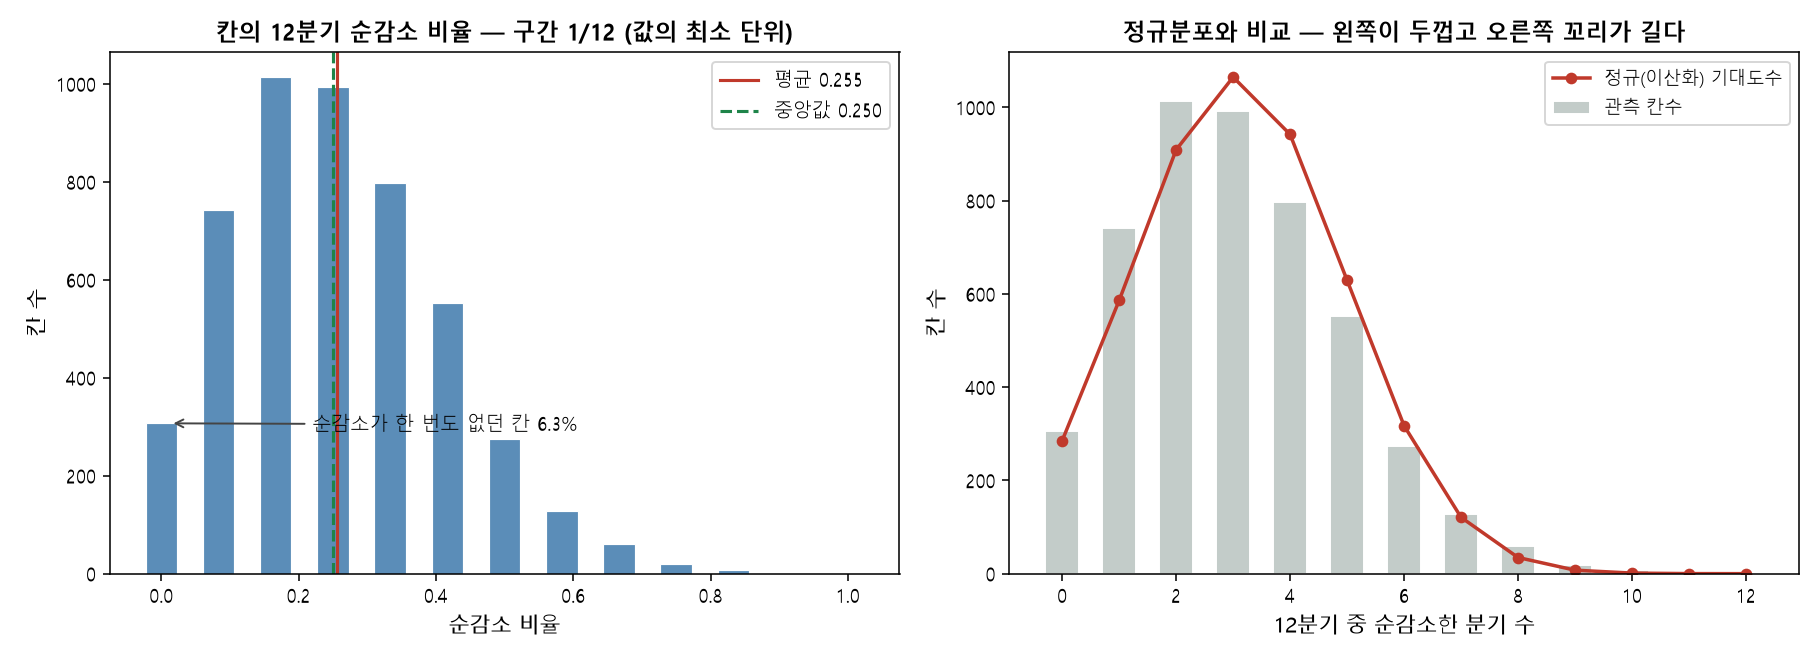

*그림 5*

읽는 법 — 왼쪽은 칸의 12분기 순감소 비율 분포임 — **0 에 봉우리가 서고 오른쪽으로 꼬리가 길다**(왜도 +0.59). 구간은 값의 최소 단위인 1/12 로 잡았음. 오른쪽은 같은 자료를 「12분기 중 순감소한 분기 수」로 세고 **정규(이산화) 기대도수를 겹친 것**임 — 관측이 왼쪽에서 더 두껍고 오른쪽 꼬리가 길어 정규분포와 어긋나는 방향이 드러남. 다른 후보 분포와의 비교는 다음 그림에서 다룸.


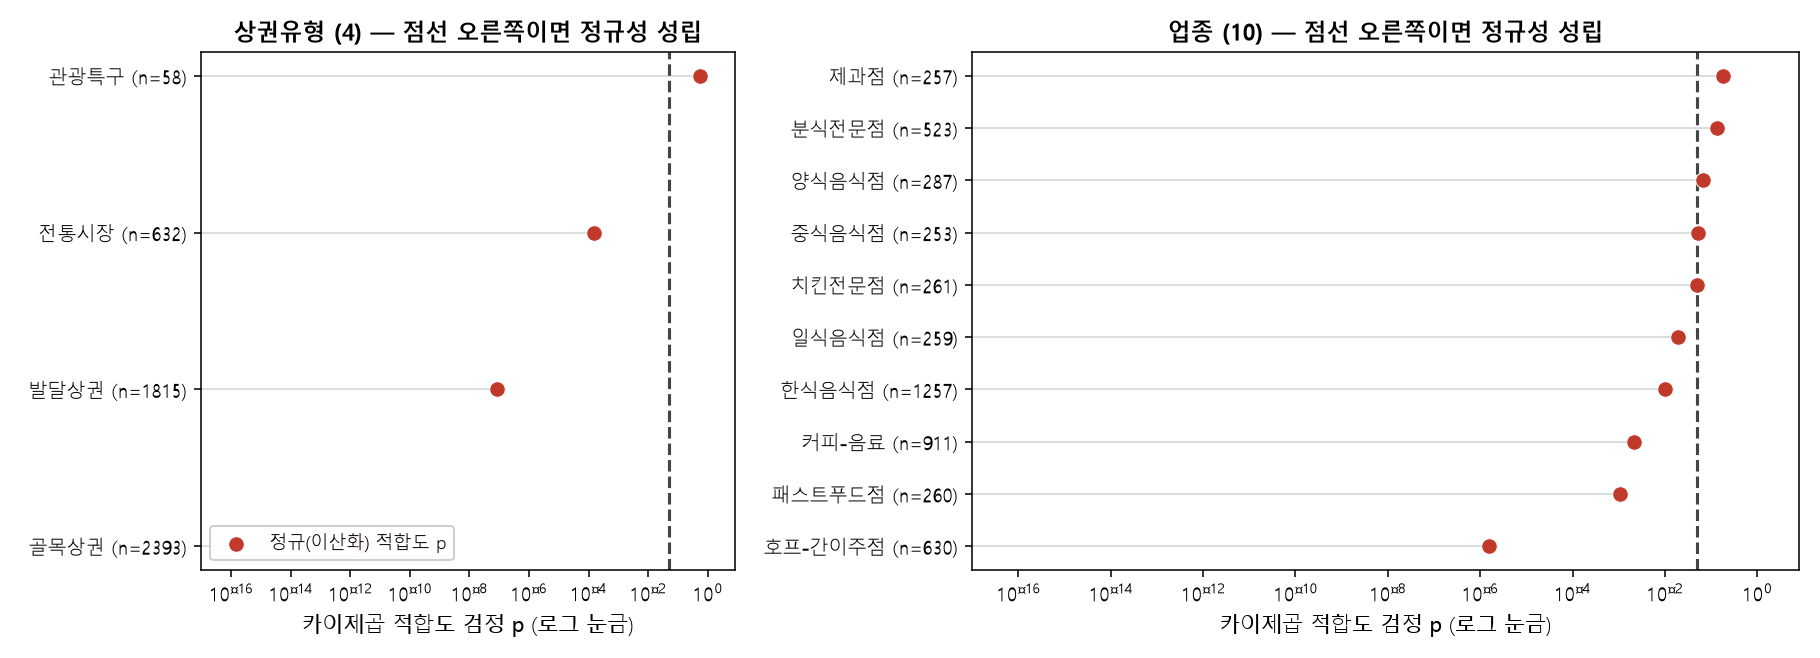

*그림 6*

읽는 법 — **상권유형과 업종을 따로 떼어** 카이제곱 적합도 검정 p 를 로그 눈금에 찍은 것임. 점선 오른쪽이면 그 분포로 설명된다는 뜻임. **정규·이항은 왼쪽에 몰리고 베타이항만 오른쪽에 있음.** 관광특구는 58칸뿐이라 셋 모두 통과하는데, 표본이 작아 어떤 분포도 기각하지 못하는 경우임.


**상권유형별 분포 모양과 정규 적합도 검정**

| 구분 | 칸수 | 왜도 | 첨도 | 0인 칸 % | Q-Q R² | 정규 적합 p |
|---|---|---|---|---|---|---|
| 발달상권 | 1,815 | 0.457 | −0.024 | 3.8 | 0.961 | **8e-08** |
| 골목상권 | 2,393 | 0.522 | 0.163 | 7.6 | 0.949 | **2e-12** |
| 전통시장 | 632 | 0.748 | 0.898 | 9.0 | 0.936 | **0.0002** |
| 관광특구 | 58 | 0.783 | 1.135 | 0.0 | 0.935 | **0.562** |

*표 16*

읽는 법 — **관광특구만 통과(p=0.562)하는데 이는 정규분포라는 증거가 아니라 「기각할 힘이 없다」는 뜻임** — 58칸뿐이어서 기대도수 5 미만 구간이 대부분 병합되고 자유도가 거의 남지 않음. 실제로 모양 지표는 네 유형 중 가장 나쁨(왜도 0.783 · 첨도 1.135 · Q-Q R² 0.935). **표본이 작으면 어떤 분포도 기각되지 않는다**는 것을 보여주는 자리이므로, 판정은 항상 칸수와 함께 읽어야 함.

기준 — **적합도 검정은 「그 분포를 따른다」가 귀무가설이므로 p ≥ 0.05 면 적합.** 왜도는 0 이 대칭이고 |왜도| 0.5 이상이면 뚜렷한 치우침, Q-Q R² 는 1.0 이 완전 정규이며 0.98 아래는 눈에 보이는 이탈로 읽음.


**업종별 분포 모양과 정규 적합도 검정**

| 구분 | 칸수 | 왜도 | 첨도 | 0인 칸 % | Q-Q R² | 정규 적합 p |
|---|---|---|---|---|---|---|
| 커피-음료 | 911 | **0.329** | −0.377 | 4.0 | **0.959** | **0.00217** |
| 양식음식점 | 287 | 0.331 | −0.446 | 8.0 | 0.961 | **0.0664** |
| 분식전문점 | 523 | 0.393 | −0.120 | 8.0 | 0.953 | **0.132** |
| 중식음식점 | 253 | 0.398 | −0.322 | 8.7 | 0.946 | **0.0522** |
| 한식음식점 | 1,257 | 0.406 | 0.127 | 5.6 | 0.961 | **0.0101** |
| 제과점 | 257 | 0.444 | −0.154 | 6.6 | 0.948 | **0.183** |
| 일식음식점 | 259 | 0.628 | 0.071 | 5.4 | 0.947 | **0.0195** |
| 치킨전문점 | 261 | 0.667 | 0.324 | 12.3 | 0.929 | **0.0491** |
| 호프-간이주점 | 630 | 0.669 | 0.055 | 6.0 | 0.947 | **2e-06** |
| 패스트푸드점 | 260 | **0.851** | 0.722 | 4.6 | **0.924** | **0.00108** |

*표 17*

읽는 법 — **왜도·첨도·Q-Q R² 는 표본 크기에 흔들리지 않는 모양 지표**이고, 마지막 열은 **이산 데이터에 맞는 카이제곱 적합도 검정**임(12분기 완전 관측 4,898칸에서 순감소 횟수 0~12 의 관측 도수를 정규분포의 기대도수와 비교, 기대도수 5 미만 구간은 이웃과 합침). p 가 0.05 보다 크면 정규분포로 설명된다는 뜻이고, **열 업종 중 넷만 통과함**.

기준 — 위 표와 같은 기준. p 가 작으면 「정규분포가 아님」이고, 표본이 작으면 무엇이든 통과하므로 항상 칸수와 함께 읽음.


**같은 자료를 베타이항에 맞추면 — 칸마다 확률이 다른 것을 허용한 경우**

| 구분 | 칸수 | 왜도 | 첨도 | 0인 칸 % | Q-Q R² | 베타이항 적합 p |
|---|---|---|---|---|---|---|
| 유형 · 발달상권 | 1,815 | 0.457 | −0.024 | 3.8 | 0.961 | 0.653 |
| 유형 · 골목상권 | 2,393 | 0.522 | 0.163 | 7.6 | 0.949 | 0.362 |
| 유형 · 전통시장 | 632 | 0.748 | 0.898 | 9.0 | 0.936 | 0.268 |
| 유형 · 관광특구 | 58 | 0.783 | 1.135 | 0.0 | 0.935 | 0.592 |
| 업종 · 커피-음료 | 911 | 0.329 | −0.377 | 4.0 | 0.959 | 0.415 |
| 업종 · 양식음식점 | 287 | 0.331 | −0.446 | 8.0 | 0.961 | 0.349 |
| 업종 · 분식전문점 | 523 | 0.393 | −0.120 | 8.0 | 0.953 | 0.352 |
| 업종 · 중식음식점 | 253 | 0.398 | −0.322 | 8.7 | 0.946 | 0.143 |
| 업종 · 한식음식점 | 1,257 | 0.406 | 0.127 | 5.6 | 0.961 | 0.0695 |
| 업종 · 제과점 | 257 | 0.444 | −0.154 | 6.6 | 0.948 | 0.907 |
| 업종 · 일식음식점 | 259 | 0.628 | 0.071 | 5.4 | 0.947 | 0.779 |
| 업종 · 치킨전문점 | 261 | 0.667 | 0.324 | 12.3 | 0.929 | 0.497 |
| 업종 · 호프-간이주점 | 630 | 0.669 | 0.055 | 6.0 | 0.947 | 0.479 |
| 업종 · 패스트푸드점 | 260 | 0.851 | 0.722 | 4.6 | 0.924 | 0.255 |

*표 18*

읽는 법 — **베타이항은 「칸마다 순감소 확률이 다르다」를 허용하는 분포임.** 이항은 모든 칸이 같은 확률 p 로 12번 시도한다고 보지만, 베타이항은 칸마다 p 가 흩어져 있다고 보고 그 흩어짐까지 모수로 추정함. **정규 적합에서 기각됐던 유형·업종이 여기서는 대부분 통과함** — 관측 도수의 모양이 정규에서 벗어난 이유가 「칸 사이 위험도 차이」였다는 뜻임.

기준 — 같은 기준(p ≥ 0.05 면 적합). 베타이항이 통과한다는 것은 「칸마다 확률이 다름」를 허용해야 관측 도수가 설명된다는 뜻임.


### 해석

따라서 ANOVA는 참고값으로 두고, 정규성 가정을 덜 요구하는 Kruskal-Wallis를 중심으로 결론을 냈음. 이는 사후에 결과를 맞춘 선택이 아니라 사전 가정 점검에서 나온 선택임.

**이 변수는 연속량이 아니라 「12분기 중 몇 번」이라는 이산량임.** 그래서 연속 분포를 전제하는 검정 대신 **이산 데이터의 표준 방법인 카이제곱 적합도 검정**을 썼다 — 순감소 횟수 0~12 의 관측 도수를 후보 분포의 기대도수와 비교하고, 기대도수 5 미만 구간은 이웃과 합쳤음.

**열 업종 중 넷만 통과한다** — 제과점(0.183)·분식전문점(0.132)·양식음식점(0.066)·중식음식점(0.052)이고, 나머지 여섯은 기각임. 상권유형에서는 관광특구(0.562)만 통과하는데 58칸뿐이라 어떤 분포도 기각하지 못하는 경우다.

참고로 같은 자료를 **베타이항**(칸마다 위험 확률이 다른 것을 허용하는 분포)에 맞추면 전체 p=0.216 으로 통과함. 「모든 칸이 같은 확률을 갖음」가 성립하지 않는다는 뜻이고, 그 이질성을 찾는 것이 이 과제의 목표임.

모양 지표로는 왜도 기준 **커피-음료가 가장 대칭(0.329 · Q-Q R² 0.959)**이고 **패스트푸드점이 가장 치우쳐 있다(0.851 · 0.924)**. Q-Q R² 는 1.0 이 완전 정규이고 0.98 아래면 눈에 보이는 이탈이므로 열 업종 모두 이탈 구간이며, 이 값은 판정용이 아니라 **업종 간 순서를 매기는 용도**다.



## 08  가설 직접 검증 — 업종 × 상권유형 · 업종 × 자치구

**핵심 한 줄 — 같은 업종이라도 상권유형에 따라 위험이 달라지지만, 효과크기 기준으로 보면 실질적 차이가 있는 업종은 세 개뿐임.**

### 왜 이 분석을 했나

전체 업종을 섞으면 “업종 효과”와 “상권유형 효과”가 붙음. 그래서 업종을 하나씩 고정한 뒤 상권유형 차이를 따로 검정했음.

### 핵심 결과

- 10개 업종 중 8개가 Bonferroni 보정 후에도 p 기준으로는 상권유형별 차이를 보였음. 다만 **표본이 크면 p는 거의 항상 유의하므로 판정은 효과크기(ε²)로 함.**
- **ε² 기준은 0.01 작음 / 0.06 중간 / 0.14 큼임.** 중간 이상은 호프-간이주점 0.1202 · 커피-음료 0.0652 · 한식음식점 0.0607 **세 업종뿐**이고, 나머지 다섯(양식 0.0483 · 분식 0.0481 · 일식 0.0448 · 제과 0.0318 · 중식 0.0300)은 「작음」 구간에 머묾.
- 패스트푸드점은 ε²=0.0161로 작고 p도 보정 기준을 통과하지 못했음.
- 치킨전문점은 ε²=0.0002로 차이가 사실상 없고 통계적으로도 유의하지 않았음.



| 항목 | 핵심 수치 / 의미 |
|---|---|
| 상권유형 차이 | 10개 업종 중 8개 유의 |
| 가장 큰 효과 | 호프·간이주점 ε²=0.1202 |
| 거의 차이 없음 | 치킨전문점 ε²=0.0002 |
| 평균 효과크기 | 상권유형 0.0465 > 자치구 0.0211 |

*표 19*


|  | 그룹수 | H | n | p-value | 유의 | eps2 |
|---|---|---|---|---|---|---|
| 호프-간이주점 | 3 | 86.9 | 709 | 0 | True | **0.1202** |
| 커피-음료 | 3 | 67.4 | 1006 | 2.0e-15 | True | **0.0652** |
| 한식음식점 | 3 | 81 | 1306 | 0 | True | **0.0607** |
| 양식음식점 | 3 | 18.8 | 352 | 8.1e-05 | True | 0.0483 |
| 분식전문점 | 3 | 32.5 | 637 | 8.8e-08 | True | 0.0481 |
| 일식음식점 | 3 | 15.6 | 307 | 4.0e-04 | True | 0.0448 |
| 제과점 | 3 | 12.9 | 347 | 0.0015 | True | 0.0318 |
| 중식음식점 | 3 | 11 | 302 | 0.0041 | True | 0.03 |
| 패스트푸드점 | 3 | 7.1 | 322 | 0.0281 | False | 0.0161 |
| 치킨전문점 | 3 | 2.1 | 341 | 0.3552 | False | **2.0e-04** |

*표 20*

읽는 법 — 업종을 하나로 고정하고 그 안에서 상권유형 간 차이를 검정한 결과임. **색이 칠해진 행은 p 가 아니라 효과크기 ε² ≥ 0.06(중간 이상)인 업종**임 — 표본이 커서 p 는 대부분 유의하게 나오므로 판정 기준을 효과크기로 두었음. ε² 는 0.01 작음 / 0.06 중간 / 0.14 큼으로 읽음.

기준 — **판정은 p 가 아니라 효과크기 ε².** 0.01 작음 / 0.06 중간 / 0.14 큼이며, 색은 0.06 이상에만 칠함. 표본이 커서 p 는 대부분 유의하게 나오므로 p 단독으로는 판정하지 않음.


### 해석

**「모든 업종이 입지에 민감함」는 결론은 틀림.** p 만 보면 8개가 유의하지만, 실질적 크기로 보면 **입지가 위험을 가르는 업종은 호프-간이주점·커피-음료·한식음식점 세 개**다. 나머지는 유의하더라도 그 차이가 작아 정책 근거로 쓰기 어려움.

업종별로 처방이 갈려야 한다는 뜻임 — 세 업종은 입지 조정·상권 선택이 효과를 낼 수 있고, 치킨전문점처럼 ε²가 0에 가까운 업종은 어디에 있든 위험 수준이 비슷하므로 입지와 무관한 지원(배달 구조·비용 구조)이 맞음.



## 09  성향점수매칭 — 조건을 맞추고 다시 비교

**핵심 한 줄 — 한식음식점은 단순 비교에서는 더 위험해 보였지만, 규모와 입지가 비슷한 곳끼리 짝지으니 오히려 순감소 위험이 낮았음.**

### 왜 이 분석을 했나

업종별 상권 규모가 너무 달라 그대로 비교하면 “업종 차이”가 아니라 “큰 상권에 많이 들어가 있는가”를 비교하게 됨.

처리군은 한식음식점으로 정했음. **표본이 가장 크고(15,677칸) 네 상권유형에 고르게 분포하기 때문**임.

### 핵심 결과

- 한식음식점을 처리군으로 정하고 점포 수·유동인구·면적·집객시설을 맞춰 1:1 매칭했음. **표본은 전체 상권 4유형 67,475칸이고, 짝은 분기와 상권유형을 정확히 일치시킨 블록 안에서만 찾았음.**
- 한식음식점 15,677칸 중 **10,030쌍**이 매칭됐고(매칭률 64.0%), 매칭 후 모든 조건 변수의 |SMD|가 0.1 아래로 내려가 비교 가능한 수준이 됐다(최대 0.015).
- **매칭 전 한식음식점은 +1.85%p 더 위험해 보였지만, 매칭 후 ATT는 −6.53%p로 방향이 반대로 바뀌었음.**
- McNemar 검정(불일치 쌍 3,929개), 상권 단위 클러스터 부트스트랩 신뢰구간, 캘리퍼·복원·유형 미고정을 바꾼 **여섯 설계가 모두 같은 방향**을 보였다(−6.47 ~ −7.65%p).
- **유형별로 나누어도 네 유형 모두 음수다** — 골목상권 −5.39 · 전통시장 −8.51 · 발달상권 −9.30%p(관광특구는 쌍 50개로 참고값). 한 유형의 산물이 아님.
- **같은 설계를 10개 업종에 모두 돌리면 「업종 자체의 위험」은 대부분 사라진다** — 규모를 맞춘 뒤에도 유의하게 남는 것은 치킨전문점 +3.35%p · 호프-간이주점 +2.34%p · 패스트푸드점 +1.97%p 세 개이고, 한식음식점은 −6.52%p 로 오히려 안전함. 중식·커피·제과·분식·양식은 유의하지 않음.



| 항목 | 핵심 수치 / 의미 |
|---|---|
| 표본 | 전체 상권 4유형 67,475칸 (특정 유형을 떼지 않음) |
| 매칭 쌍 | 10,030쌍 · 처리군 매칭률 64.0% |
| 매칭 후 \|SMD\| | 최대 0.015 (기준 0.1 통과) |
| 단순 격차 | +1.85%p |
| 매칭 후 ATT | −6.53%p |
| 95% CI | −7.83%p ~ −5.11%p |
| 민감도 6종 | −6.47%p ~ −7.65%p · 부호 일치 |

*표 21*


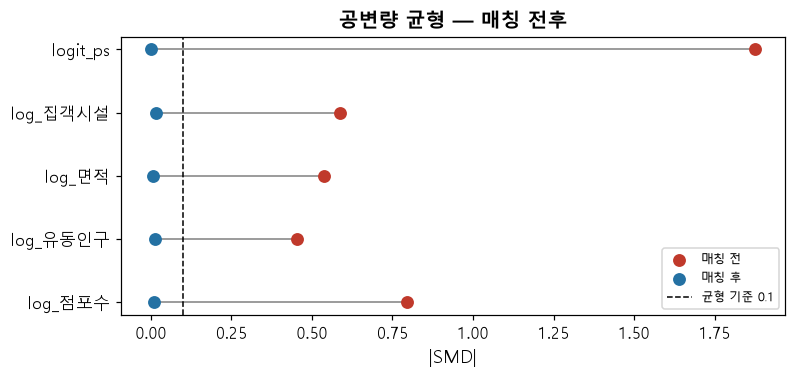

*그림 7*

읽는 법 — 붉은 점이 매칭 전, 파란 점이 매칭 후 |SMD| 임. 점선 0.1 왼쪽으로 모두 들어와야 비교가 성립함.


|  | 쌍수 | 처리군_순감소율 | 대조군_순감소율 | ATT(%p) |
|---|---|---|---|---|
| 골목상권 | 6848 | 0.228 | 0.282 | **-5.39** |
| 관광특구 | 50 | 0.34 | 0.46 | **-12** |
| 발달상권 | 1710 | 0.347 | 0.44 | **-9.3** |
| 전통시장 | 1422 | 0.211 | 0.296 | **-8.51** |

*표 22*

읽는 법 — 유형별로 따로 낸 ATT 임. 쌍이 50개뿐인 관광특구는 참고용이고, 나머지 세 유형에서 부호가 같은지가 판정 근거임.

기준 — 쌍이 100개 이상인 유형만 판정 대상. **네 유형에서 부호가 같은지**가 「한 유형의 산물이 아닌가」의 기준임.


**업종 10종을 각각 처리군으로 두고 같은 설계로 매칭한 결과**

| 업종 | 처리군 칸수 | 매칭 쌍 | 매칭 후 최대 |SMD| | 단순 격차(%p) | ATT(%p) | McNemar p |
|---|---|---|---|---|---|---|
| 한식음식점 | 15,677 | 10,030 | 0.015 | +1.85 | −6.52 | 1.6e-25 |
| 중식음식점 | 3,646 | 3,646 | 0.048 | −3.88 | −0.77 | 0.439 |
| 커피-음료 | 12,046 | 12,039 | 0.020 | +1.00 | −0.22 | 0.702 |
| 제과점 | 4,133 | 4,132 | 0.039 | −3.14 | +0.85 | 0.363 |
| 분식전문점 | 7,570 | 7,566 | 0.056 | −2.06 | +0.90 | 0.189 |
| 양식음식점 | 4,172 | 4,169 | 0.050 | +1.20 | +1.30 | 0.181 |
| 일식음식점 | 3,696 | 3,696 | 0.042 | +0.18 | +1.92 | 0.0559 |
| 패스트푸드점 | 3,901 | 3,901 | 0.061 | −1.63 | +1.97 | 0.0376 |
| 호프-간이주점 | 8,448 | 8,448 | 0.031 | +3.88 | +2.34 | 5.3e-04 |
| 치킨전문점 | 4,186 | 4,145 | 0.101 | −5.31 | +3.35 | 9.9e-05 |

*표 23*

읽는 법 — **색이 칠해진 네 업종은 「규모·유동인구·면적·집객시설이 비슷한 곳끼리 비교해도 위험 차이가 남는 업종」임.** 붉은 셋(치킨전문점 +3.35 · 호프-간이주점 +2.34 · 패스트푸드점 +1.97%p)은 조건을 맞춰도 더 위험한 쪽이고, 초록 하나(한식음식점 −6.52%p)는 오히려 더 안전한 쪽임. **색이 없는 여섯 업종은 조건을 맞추면 차이가 사라지는 업종** — 위험이 업종에서 온 것이 아니라 입지·규모에서 왔다는 뜻임. 색 기준은 McNemar p < 0.05 이고 그 안에서 ATT 부호로 초록·붉은색을 나눔(일식음식점 p=0.0559 는 경계 위라 색이 없으나 크기는 패스트푸드점과 거의 같음). 한식음식점만 결과를 보기 전에 선험적으로 고정한 처리군이고 나머지 아홉은 같은 설계를 반복한 탐색적 결과임(다중비교 보정 없음). 치킨전문점은 매칭 후 최대 |SMD| 0.101 로 균형 기준을 살짝 넘겨 해석에 주의가 필요함.

기준 — 색은 **McNemar p < 0.05** 인 업종에만 칠하고 그 안에서 **ATT 부호**로 초록(음수)·붉은색(양수)을 나눔. 매칭 후 최대 |SMD| 는 0.1 미만이어야 비교가 성립함.


### 해석

따라서 “한식음식점 자체가 위험하다”는 단순 해석은 채택되지 않았음. **단순 비교의 +1.85%p는 「한식이라서」가 아니라 「한식이 큰 상권에 몰려 있어서」 생긴 값이었음.**

다만 ATT는 **짝을 찾을 수 있었던 한식음식점 집단(64%)에서의 평균 차이**이므로 모든 한식음식점에 그대로 일반화할 수 없고, 매칭은 관측된 공변량만 맞추므로 임대료처럼 데이터에 없는 변수의 영향은 남아 있음.

**부호 반전이 한식에서만 나오는 것이 아님.** 치킨전문점은 단순 비교에서 −5.31%p(안전해 보임)였으나 규모를 맞추면 +3.35%p 로 뒤집히고, 패스트푸드점도 −1.63 → +1.97%p 로 바뀜. 즉 **단순 집계로 만든 업종 위험 순위는 방향까지 틀릴 수 있다** — 작은 상권에 몰려 있는 업종은 사건이 드물어 안전해 보이고, 큰 상권에 몰려 있는 업종은 그 반대다.



## 10  사후검정 — 어느 상권유형이 실제로 다른가

**핵심 한 줄 — 전체적으로 차이가 있다는 것만으로는 부족해, Dunn 사후검정으로 상권유형을 두 개씩 비교했음. 전통시장과 골목상권만 뚜렷하게 구분되지 않았음.**

### 왜 이 분석을 했나

Kruskal-Wallis는 “어딘가 다름”까지만 알려줌. 정책적으로는 정확히 어느 유형과 어느 유형 사이가 다른지 알아야 함.

### 핵심 결과

- 상권유형 4개에서 가능한 6쌍 중 5쌍이 Bonferroni 보정 후에도 유의했음.
- 전통시장과 골목상권은 p=0.321로 유의한 차이가 없었음.
- 발달상권은 전통시장·골목상권보다 높았고, 관광특구는 세 유형 모두보다 높았음.
- **p 는 6쌍 중 5쌍을 유의로 판정하지만, 효과크기로 보면 그림이 달라진다** — Cliff δ 가 중간(0.33) 이상인 세 쌍은 모두 관광특구가 걸려 있고 그 유형은 58칸뿐임. 쓸 수 있는 비교는 발달상권↔전통시장 0.252 · 골목상권↔발달상권 0.209 로 「작음~중간」임.



| 항목 | 핵심 수치 / 의미 |
|---|---|
| 순위 | {전통시장 ≈ 골목상권} < 발달상권 < 관광특구 |
| p 기준 판정 | 6쌍 중 5쌍 유의 (전통시장↔골목상권만 p=0.321 비유의) |
| 효과크기 기준 | 중간 이상은 관광특구뿐이고 그 유형은 58칸 · 나머지는 δ 0.13~0.21 「작음」 |
| 실무 단위 | 유형 사이 차이보다 같은 유형 안의 폭이 크므로 개별 상권 |

*표 24*


|  | median | mean | size |
|---|---|---|---|
| 전통시장 | 0.1667 | 0.2176 | 775 |
| 골목상권 | 0.25 | 0.2282 | 2922 |
| 발달상권 | 0.25 | 0.2894 | 1932 |
| 관광특구 | 0.3333 | 0.3779 | 58 |

*표 25*

읽는 법 — 유형별 중앙값·평균·칸수임. 정렬은 중앙값이 낮은 쪽부터임.

기준 — 중앙값·평균·칸수 서술. 중앙값이 같아도 평균 순위가 다를 수 있어 순위 기반 검정이 필요함.


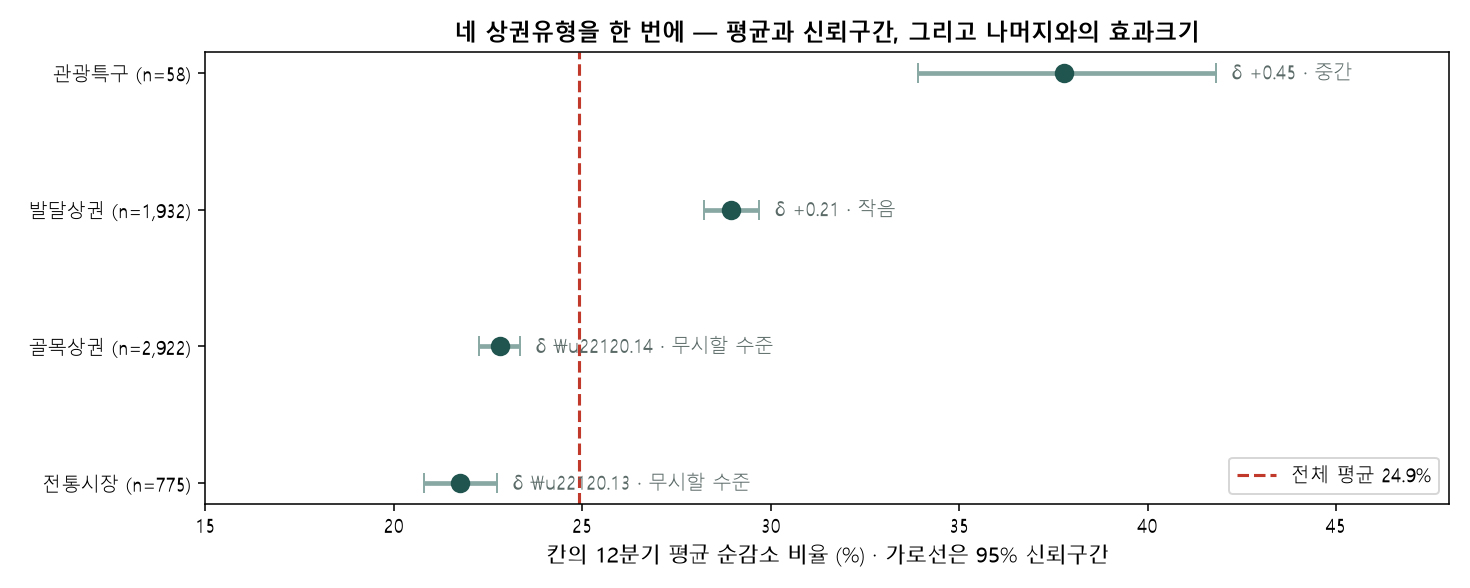

*그림 8*

읽는 법 — 점이 유형별 평균 순감소 비율, 가로선이 95% 신뢰구간임. **신뢰구간이 겹치지 않으면 두 유형이 다르다고 볼 수 있음** — 전통시장과 골목상권은 겹치고, 발달상권은 떨어져 있으며, 관광특구는 구간 자체가 넓음. 오른쪽 라벨이 나머지 세 유형과 비교한 효과크기임.


**네 상권유형을 한 번에 — 각 유형 대 나머지**

| 상권유형 | 칸수 | 평균 순감소 비율(%) | 95% CI | 나머지와 평균차(%p) | Cliff δ | |δ| 판정 |
|---|---|---|---|---|---|---|
| 전통시장 | 775 | 21.8 | 20.8 ~ 22.7 | −3.64 | −0.133 | 무시할 수준 |
| 골목상권 | 2,922 | 22.8 | 22.3 ~ 23.3 | −4.29 | −0.144 | 무시할 수준 |
| 발달상권 | 1,932 | 28.9 | 28.2 ~ 29.7 | +6.11 | +0.210 | 작음 |
| 관광특구 | 58 | 37.8 | 33.9 ~ 41.8 | +13.01 | +0.453 | 중간 |

*표 26*

읽는 법 — 사후검정은 방법론상 쌍별이지만, 읽기 쉽게 **각 유형을 「나머지 세 유형」과 비교해 네 줄로 정리**했음. Cliff δ 는 「그 유형의 칸이 나머지보다 높을 확률 − 그 반대 확률」이고 0.147 작음 / 0.33 중간 / 0.474 큼으로 읽음. **색 기준은 「칸수 100 이상이면서 |δ| 0.147 이상」임** — 관광특구는 δ 0.453 으로 가장 크지만 58칸(독립 상권 6곳)이고 신뢰구간이 33.9~41.8% 로 넓어 제외했고, 그래서 **실제로 쓸 수 있는 유형 중에서는 발달상권(δ 0.210)만 색이 칠해짐**. 나머지 세 유형은 δ 0.13~0.21 로 「작음」 구간이며, **전통시장과 골목상권은 δ 가 −0.133 / −0.144 로 사실상 같은 자리**임.

기준 — **Cliff δ 는 0.147 작음 / 0.33 중간 / 0.474 큼**(Romano 등의 관행값). 확률로 읽으면 δ 0.147 ≈ 57%, 0.210 ≈ 60.5%, 0.453 ≈ 73% 로 한쪽이 더 높을 확률임. 색 기준은 「칸수 100 이상 + |δ| 0.147 이상」.


### 해석

**따라서 「네 유형이 서로 다름」는 진술은 p 가 만든 것이고, 실질적 크기는 작음.** 유형 사이의 차이보다 같은 유형 안의 폭이 크므로, 대응 단위를 유형이 아니라 상권으로 잡아야 한다는 근거가 여기서도 나옴.



## 11  모델 선정

**핵심 한 줄 — 다섯 모델의 AP가 0.398~0.408에 몰려 있었고, 그 안에서 검증 AP가 가장 높은 랜덤포레스트를 대표 모델로 채택했음.**

### 왜 이 분석을 했나

**연구 목적이 「다음 분기 순감소 상권을 위험순위 위쪽에 얼마나 잘 올려놓느냐」이고, 실제 운영에서도 상위 50·100·300개를 골라 정밀도와 Lift(향상도)로 평가함.** 그래서 주 지표를 **순위 상단 집중도를 재는 AP**로 두고, 작동점 값은 고른 뒤에 함께 보고하는 방식으로 나눴음.

복잡한 모델이 단순 모델보다 확실히 우수한지 확인하고, 불균형 데이터에서 정확도 대신 적절한 평가 지표를 사용하기 위해 비교했음.

주지표는 AP(Average Precision)로 정했음. **AP 는 모델이 실제 순감소 상권을 위험순위 상단에 얼마나 잘 모아 놓았는지를 보는 지표**로, 위험도가 높은 순으로 줄을 세운 뒤 실제 순감소 칸을 만날 때마다의 정밀도를 평균한 값임. **AP 를 쓰는 이유는 두 가지임. 첫째, 임계값을 고르지 않고 순위 전체를 평가하므로 「위험한 곳을 위쪽에 올렸는가」라는 이 연구의 목적과 그대로 맞음** — 정확도·F1 은 임계값 하나를 먼저 정해야 계산되는데, 양성률 26%의 소수 사건에서는 그 임계값이 결과를 좌우함. **둘째, 실제로 도달할 수 있는 곡선에 더 가까움.** 점 사이를 직선으로 잇는 사다리꼴 계산은 PR 공간에서 도달할 수 없는 작동점을 넓이로 세어 이론적으로 부적절한데(Davis & Goadrich 2006), 테스트 분기에서 실제로 재보면 **AP 는 기준과 0.0001, 사다리꼴은 0.0008 어긋남**(기준 0.4134 · AP 0.4132 · 사다리꼴 0.4125). **다만 그 격차는 곡선의 점이 적을 때 커지는 것이고, 5,480개인 우리 표본에서는 어느 쪽을 써도 결론이 같음.**

### 핵심 결과

- 의사결정나무, 랜덤포레스트, 로지스틱 회귀, 선형 SVM, XGBoost를 같은 검증 분기에서 비교했음.
- 양성 비율이 약 25%이므로 정확도는 주 지표로 쓰지 않았음. 모두 0으로 예측해도 정확도는 약 74.7%가 나오기 때문임.
- 주 지표는 AP를 사용했음. **AP 는 재현율이 늘어난 지점의 정밀도를 그 증가분으로 가중해 더한 값**(`average_precision_score`)이고, 점 사이를 직선으로 잇는 `auc(recall, precision)` 과는 계산이 다름. **랜덤포레스트 0.408 · 선형 SVM 0.406 · 로지스틱 회귀 0.406 · 의사결정나무 0.398 · XGBoost 0.398** 이었음.
- **대표 모델은 검증 AP가 가장 높은 랜덤포레스트로 정했음.** 테스트 분기는 이 선택에 쓰지 않았음 — 고른 근거와 보고하는 근거가 같은 자료가 되면 성능이 낙관 쪽으로 치우치기 때문임.
- **한 분기의 우연인지 따로 확인했음.** 학습 종료 시점을 옮겨 가며 테스트 분기를 여섯 번 바꿔 AP를 다시 측정했더니 **여섯 분기 전부 랜덤포레스트가 XGBoost보다 높았음**(0.411 ± 0.023 대 0.396 ± 0.015). 부호검정으로는 양측 p=0.031 임. 다만 여섯 비교가 학습 구간을 공유하므로 서로 독립이 아니고, 그만큼 보수적으로 읽어야 함.
- **그래도 실제로 쓰는 구간에서는 우열이 갈리지 않음.** 상위 50·100·200·300·500칸의 정밀도로 바꿔 보면 두 모델의 평균 차이가 −0.005~+0.033으로 **모든 구간에서 그 추정치의 표준오차(±0.022~±0.069)보다 작음.** 상위 100칸으로 환산하면 1~2칸 차이임.
- **작동점으로 판단해도 결론이 같음.** 같은 분할·같은 테스트 분기에서 상위 k칸 정밀도를 비교하면 **상위 100칸 62.0% 대 60.0%, 상위 300칸 55.0% 대 53.3%로 랜덤포레스트가 높고**, 상위 50칸에서만 70.0% 대 72.0%로 XGBoost가 높음 — 50칸 표본에서 정확히 1칸 차이이고 표준오차(±0.069) 안임. 전체 Lift(향상도)도 1.627 대 1.522임. **순위 전체를 보는 AP와 실제로 쓰는 작동점이 같은 방향을 가리킴.**
- 랜덤포레스트는 트리 기반이라 **TreeSHAP으로 변수별 기여도를 정확히 분해**할 수 있음(로지스틱 회귀·선형 SVM에는 대응 도구가 없음). AP가 0.002 차이로 그 둘과 사실상 같았으므로, **같은 성능이라면 뒤에서 해석까지 이어갈 수 있는 쪽**이 필요했음.
- 그래서 15절의 2단계 모형에도 같은 방식의 SHAP 분석을 적용해, **변수의 영향이 1단계와 2단계에서 어떻게 달라지는지 직접 비교**할 수 있었음(17절).
- **F1과 정확도는 선택 기준에서 제외했음.** 둘 다 하나의 임계값을 전제로 하는 지표인데, 우리는 임계값이 아니라 **상위 k칸이라는 개수**로 운영함. 특히 상위 100칸에서는 재현율의 상한이 100 ÷ 1,423 = 7.0%로 이미 정해져 있어, 그 지점의 F1은 모델의 우열이 아니라 **k가 작다는 사실**을 다시 말할 뿐임.
- **선택 기준을 바꿔 보는 검증도 했음.** 분기 t의 값으로 모델을 고른 뒤 아직 보지 않은 분기 t+1에서 평가했더니, **AP로 고른 쪽이 다음 분기 AP가 가장 높았음(0.414).** 작동점으로 고르면 분기마다 1위가 바뀌어 여섯 분기 동안 3~4회 갈아타게 되는데, **선택 기준이 흔들린다는 것은 그 기준이 실력이 아니라 그 분기의 우연을 따라가고 있다는 뜻임.**



**AP 와 PR-AUC 는 계산식이 다르다.** AP 는 재현율이 늘어난 지점의 정밀도를 그 증가분으로 가중해 더하고, PR-AUC 는 점과 점 사이를 직선으로 이어 넓이를 잰다. 「실제 곡선」은 임계값을 섞어 도달할 수 있는 곡선의 넓이임(Davis & Goadrich 2006).

| 계산 방식 | 12칸 예시 | 기준 대비 | 실제 테스트 5,479칸 | 기준 대비 |
|---|---|---|---|---|
| 실제 곡선 (기준) | 0.5748 | — | 0.4134 | — |
| **AP** | 0.5787 | ▲ +0.0039 | **0.4132** | ▼ −0.0001 |
| PR-AUC (사다리꼴) | 0.4894 | ▼ −0.0855 | 0.4125 | ▼ −0.0008 |

곡선의 점이 12개뿐일 때는 두 방식이 0.09 넘게 벌어지지만, 점이 5,480개인 테스트 분기에서는 **두 방식 모두 기준과 0.001 안에서 일치**한다. 그중 **AP 가 가장 가깝다.**


| 항목 | 핵심 수치 / 의미 |
|---|---|
| 랜덤포레스트 | AP 0.408 |
| 선형 SVM | 0.406 |
| 로지스틱 회귀 | 0.406 |
| 의사결정나무 | 0.398 |
| XGBoost | 0.398 |

*표 27*


|  | AP | ROC-AUC | F1 | 정밀도 | 재현율 | 정확도 | Lift |
|---|---|---|---|---|---|---|---|
| 랜덤포레스트 | 0.408 | 0.676 | 0.401 | 0.401 | 0.401 | 0.697 | 1.584 |
| 선형 SVM | 0.406 | 0.675 | 0.418 | 0.418 | 0.418 | 0.705 | 1.652 |
| 로지스틱 회귀 | 0.406 | 0.675 | 0.417 | 0.417 | 0.417 | 0.705 | 1.646 |
| 의사결정나무 | 0.398 | 0.667 | 0.420 | 0.401 | 0.441 | 0.692 | 1.585 |
| XGBoost | 0.398 | 0.665 | 0.405 | 0.405 | 0.405 | 0.699 | 1.601 |

*표 28*

읽는 법 — 다섯 모델을 같은 검증 분기에서 비교한 것이고 주지표는 AP 임. 정확도 열은 참고용임.

기준 — **주지표는 AP** — **모델이 실제 순감소 상권을 위험순위 상단에 얼마나 잘 모아 놓았는지**를 보는 지표임. 위험도가 높은 순으로 줄을 세운 뒤 위에서부터 훑어 내려가며 실제 순감소 칸을 만날 때마다의 정밀도를 평균한 값이라, **1.0 에 가까울수록 진짜 위험한 칸이 앞쪽에 몰려 있다는 뜻**이고 무작위로 세우면 기저율(0.260) 근처가 됨. 양성률 26% 인 소수 사건이라 정확도는 판정에 쓰지 않음(전부 0 으로 찍어도 74.7%). Lift(향상도) 는 1.0 이 무작위. **F1·정밀도·재현율 세 열이 같은 값인 것은 우연이 아님** — 「기저율만큼만 위험으로 찍는」 임계값을 써서 찍은 개수가 실제 양성 개수와 같아지므로 헛경보와 놓침이 같아지고, 그러면 정밀도=재현율=F1 이 됨. 의사결정나무만 다른 것은 점수 동점 때문에 정확히 그 개수로 자르지 못해서임. **즉 이 표의 F1 은 정밀도를 다시 적은 것이라 선택 근거가 되지 못하고, 판정은 AP 로 함.**


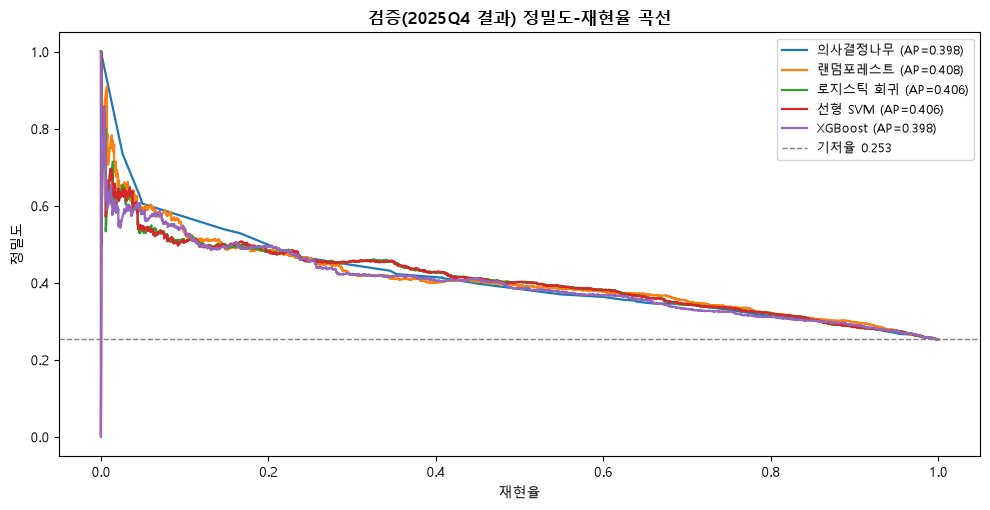

*그림 9*

읽는 법 — 곡선이 위로 붙을수록 좋고 점선이 기저율임. 다섯 곡선이 겹쳐 보이는 것이 「모델 선택이 결론을 바꾸지 않음」는 근거임.


**테스트 분기를 여섯 번 바꿔 다섯 모델을 모두 다시 측정한 AP — 학습은 언제나 그 분기 이전만 사용**

| 모델 | 2024Q3 | 2024Q4 | 2025Q1 | 2025Q2 | 2025Q3 | 2025Q4 | 평균 ± 표준편차 |
|---|---|---|---|---|---|---|---|
| 의사결정나무 | 0.369 | 0.428 | 0.366 | 0.403 | 0.398 | 0.402 | 0.394 ± 0.024 |
| 랜덤포레스트 | 0.386 | 0.449 | 0.389 | 0.421 | 0.408 | 0.417 | 0.411 ± 0.023 |
| 로지스틱 회귀 | 0.401 | 0.434 | 0.386 | 0.410 | 0.406 | 0.406 | 0.407 ± 0.016 |
| 선형 SVM | 0.401 | 0.434 | 0.385 | 0.411 | 0.406 | 0.405 | 0.407 ± 0.016 |
| XGBoost | 0.380 | 0.409 | 0.375 | 0.403 | 0.398 | 0.411 | 0.396 ± 0.015 |

*표 29*

읽는 법 — **검증 한 분기의 결과가 우연인지 확인한 표임.** 학습 종료 시점을 옮겨 가며 여섯 번 다시 측정했음. **랜덤포레스트가 여섯 분기 중 다섯 분기에서 가장 높고**, 나머지 한 분기(2024Q3)에서도 1위와 0.015 차이임. **분기 자체의 난이도 차가 모델 간 차이보다 큼** — 2024Q4 는 다섯 모델 모두 높고 2024Q3·2025Q1 은 모두 낮음. 따라서 분기끼리 비교하지 말고 **같은 분기 안에서 다섯 값을 비교**해야 함. 초록으로 칠한 행이 평균이 가장 높은 모델임.

기준 — **여섯 분기 전부 같은 방향인지**가 기준임. 한 분기라도 뒤집히면 검증 한 분기의 결과를 신뢰할 수 없다는 뜻임. 분기별 절대값은 그 분기의 난이도를 함께 담고 있으므로 분기 간 비교가 아니라 **같은 분기 안에서 두 열을 비교**해야 함.


**같은 다섯 모델을 작동점(상위 k칸 정밀도)으로 다시 측정 — 여섯 분기 평균**

| 모델 | 상위 50칸 | 상위 100칸 | 상위 200칸 | 상위 300칸 | 상위 500칸 |
|---|---|---|---|---|---|
| 의사결정나무 | 0.720 | 0.625 | 0.561 | 0.534 | 0.485 |
| 랜덤포레스트 | 0.693 | 0.613 | 0.553 | 0.520 | 0.497 |
| 로지스틱 회귀 | 0.600 | 0.595 | 0.551 | 0.533 | 0.492 |
| 선형 SVM | 0.607 | 0.598 | 0.553 | 0.527 | 0.493 |
| XGBoost | 0.660 | 0.618 | 0.537 | 0.507 | 0.476 |
| 추정 표준오차 | ±0.069 | ±0.049 | ±0.035 | ±0.028 | ±0.022 |

*표 30*

읽는 법 — **작동점만으로는 모델을 고를 수 없음을 보여주는 표임.** **마지막 줄이 판단의 잣대임** — 상위 100칸에서 다섯 모델의 폭은 0.595~0.625(0.030)인데 그 자리의 추정 표준오차는 ±0.049 로 더 큼. 즉 **다섯 모델의 차이가 측정 오차 안에 들어감.** **분기가 바뀌면 1위가 네 모델 사이를 오감** — 상위 100칸 기준 1위는 여섯 분기에서 의사결정나무·랜덤포레스트·선형 SVM·XGBoost 로 갈림. **의사결정나무가 작은 k 에서 높게 보이는 것은 점수가 거칠기 때문임** — 깊이 6이라 서로 다른 점수가 50개뿐이고 상위 50칸을 자르는 지점에 동점이 61칸 걸려 있어, 그 목록은 순위가 아니라 임의로 잘린 덩어리임. 초록 행은 AP 로 채택한 모델임.

기준 — **마지막 줄의 추정 표준오차와 비교해 판정함** — 정밀도 0.6 부근에서 √(0.6×0.4÷k) 로 계산한 값임. **모델 간 차이가 그 줄보다 작으면 「가릴 수 없음」임.** k 가 작을수록 표본이 적어 오차가 커지므로, 상위 50칸의 큰 차이가 상위 500칸의 작은 차이보다 오히려 근거가 약함.


**계산 방식에 따라 값이 얼마나 갈리는가 — 실제로 도달할 수 있는 곡선을 기준으로**

| 계산 방식 | 12칸 예시 | 기준 대비 | 실제 테스트 분기 5,479칸 | 기준 대비 |
|---|---|---|---|---|
| 실제 곡선 (기준) | 0.5748 | — | 0.4134 | — |
| AP | 0.5787 | ▲ +0.0039 | 0.4132 | ▼ −0.0001 |
| PR-AUC (사다리꼴) | 0.4894 | ▼ −0.0855 | 0.4125 | ▼ −0.0008 |

*표 31*

읽는 법 — **「기준」은 임계값을 섞어 실제로 도달할 수 있는 곡선의 넓이임**(Davis & Goadrich 2006). 두 계산 방식은 그것을 근사한 값이므로 **기준과의 차이가 작을수록 정확한 계산**임. **곡선의 점이 12개뿐일 때는 PR-AUC 가 기준보다 0.0855 나 낮게 나오지만, 점이 5,480개인 실제 테스트 분기에서는 두 방식 모두 기준과 0.001 안에서 일치함.** 즉 **scikit-learn 문서가 경고하는 「PR-AUC 가 너무 낙관적일 수 있다」는 곡선의 점이 드문드문할 때의 이야기이고, 우리 표본에서는 해당하지 않음** — 오히려 근소하게 낮게 나옴. **그래서 AP 를 쓰는 근거는 「값이 크다」가 아니라 「기준에 더 가깝다」임 — 다만 우리 표본에서는 그 차이조차 0.001 안이라 결론을 바꾸지 않음.**

기준 — **「기준 대비」 열이 판정 기준임** — 0 에 가까울수록 정확한 계산임. 두 방식의 우열이 아니라 **표본이 커지면 차이가 사라진다는 것**을 읽는 표임.


**선택 기준 자체를 검증 — 분기 t 에서 그 지표로 고른 모델을 분기 t+1 에서 평가(전진 검증 5회)**

| 모델을 고른 기준 | 다음 분기 AP | 다음 분기 상위 100칸 | 여섯 분기에서 1위가 바뀐 횟수 |
|---|---|---|---|
| AP | 0.414 | 0.600 | 1회 (5/6분기 랜덤포레스트) |
| 상위 50칸 정밀도 | 0.409 | 0.600 | 3회 |
| 상위 100칸 정밀도 | 0.407 | 0.624 | 4회 |
| 상위 300칸 정밀도 | 0.404 | 0.594 | 3회 |

*표 32*

읽는 법 — **「여러 지표를 다 비교하고 제일 높은 것으로 고르면 되지 않나」를 실제로 시험한 표임.** 분기 t 의 값으로 모델을 고른 뒤 **아직 보지 않은 분기 t+1** 에서 그 모델을 평가했음. **AP 로 고른 쪽이 다음 분기 AP 가 가장 높음(0.414).** 더 중요한 것은 오른쪽 열임 — **작동점으로 고르면 분기마다 다른 모델이 1위가 되어 3~4회 갈아타게 되지만, AP 로 고르면 한 번만 바뀜.** 선택 기준이 흔들린다는 것은 그 기준이 실력이 아니라 그 분기의 우연을 좇고 있다는 뜻임. 그래서 **선택은 AP 하나로 하고, 상위 k칸 정밀도·재현율은 고른 뒤에 「이 모델로 무엇을 얻는가」를 보고하는 자리(12절)에 둠.**

기준 — **「다음 분기」 두 열이 판정 기준임** — 고를 때 쓴 분기가 아니라 아직 보지 않은 분기에서의 값이므로 선택 기준의 실제 성능임. 오른쪽 열은 **적을수록 좋음**(기준이 안정적이라는 뜻).


### 해석

**오버샘플링을 분할 전에 적용하지 않은 이유는 성능이 부풀기 때문임.** 소수 클래스를 복제한 뒤 나누면 같은 칸이 학습과 검증에 동시에 들어가, 모델이 이미 본 행을 다시 맞히면서 점수가 올라감. 그래서 불균형은 **모델별 클래스 가중치**로만 다뤘음 — 가중치는 행을 늘리지 않으므로 그 위험이 없음. **중요한 결론은 「랜덤포레스트가 최고」가 아니라, 서로 다른 다섯 모델의 성능이 거의 같아 현재 성능 한계가 알고리즘보다 데이터 변수에 더 가까워 보인다는 점임.**



## 12  선정 규모 — 몇 곳을 위험 대상으로 볼 것인가

**핵심 한 줄 — 모델은 많은 곳을 넓게 잡을 때보다, 실제 담당자가 볼 수 있는 상위 수십~수백 곳을 우선 선별할 때 가장 유용했음.**

### 왜 이 분석을 했나

11절에서 순위를 잘 세우는 모델을 골랐다면, **이 절은 그 순위를 어디서 자를 것인가**를 정함. **자르는 지점에 따라 정밀도와 재현율이 정반대로 움직이므로 값 하나가 아니라 구간 전체를 제시함.**

경보 대상을 몇 곳으로 자르느냐에 따라 정밀도와 재현율이 달라짐. 테스트 결과를 본 뒤 기준을 고르면 과적합이므로, 선정 규모는 검증 분기에서 먼저 정했음.

**재현율이 아니라 정밀도로 작동점을 고르는 이유는 재현율이 찍는 개수에 딸려 오는 값이기 때문임.** 찍는 개수 k 를 정하면 재현율 = 정밀도 × k ÷ (실제 순감소 수)이므로, **같은 k 안에서 두 값은 상수배 관계라 순서가 같고, k 를 늘리면 재현율은 언제나 올라감.** 재현율을 기준으로 삼으면 「전부 찍기」가 항상 1위가 되어 고를 것이 없어짐. **정밀도는 k 가 늘면 대체로 떨어지므로 「어디까지가 남는 장사인가」를 가릴 수 있는 유일한 축임.**

### 핵심 결과

- **작동점은 두 조건을 함께 걸어 정했음.** 첫째, 테스트를 보고 고르면 테스트가 검증이 되어 버리므로 **검증 분기에서만 판단**했음. 둘째, **정밀도가 기저율의 2배 이상을 유지하면서 점검 인력이 감당할 수 있는 규모**여야 함. 검증에서 정밀도가 가장 높은 지점은 상위 50칸(0.640)이었지만 그 규모로는 실제 순감소의 2.5%만 잡히므로, **작동점은 상위 100~300칸으로 두고 그 구간을 테스트 분기에 그대로 적용했음.**
- 테스트에서 **상위 100칸은 모델 정밀도 62.0%**로 점포 수 기준 46.0%보다 높았고(기저율의 2.39배), **상위 300칸은 55.0% 대 49.3%**였음.
- 구간 밖도 함께 보면 상위 50칸은 70.0% 대 38.0%로 정밀도가 가장 높지만 **포착이 35칸에 그치고**, 상위 500칸은 51.4% 대 46.4%로 **정밀도가 기저율의 2배 아래(1.98배)로 내려감.**
- 선정 규모가 커질수록 모델과 점포 수 기준의 차이가 줄었고, **상위 1,285개(기저율만큼 찍는 지점)에 이르면 42.4% 대 42.7%로 점포 수 기준이 근소하게 높아졌음.**



| 항목 | 핵심 수치 / 의미 |
|---|---|
| 상위 50개 | 모델 70.0% · 점포 수 38.0% |
| 상위 100개 | 62.0% · 46.0% |
| 상위 300개 | 55.0% · 49.3% |
| 상위 100개 재현율 | 전체 실제 순감소의 4.4%만 포착 |

*표 33*


|  | 검증 정밀도 | 검증 재현율 | 정밀도 ÷ 기저율 |
|---|---|---|---|
| 50 | 0.640 | 0.023 | 2.529 |
| 100 | 0.600 | 0.043 | 2.371 |
| 200 | 0.580 | 0.083 | 2.292 |
| 300 | 0.513 | 0.111 | 2.028 |
| 500 | 0.492 | 0.177 | 1.944 |
| 800 | 0.451 | 0.259 | 1.783 |
| 1285 | 0.409 | 0.378 | 1.617 |
| 2000 | 0.384 | 0.552 | 1.517 |

*표 34*

읽는 법 — 검증 분기에서 찍는 칸 수를 바꿔 가며 정밀도를 본 것임. 정밀도만 보면 상위 50칸(0.640)이 1위지만 그 규모로는 실제 순감소의 2.5%만 잡힘. **정밀도가 기저율의 2배 이상을 유지하면서 점검 인력이 감당할 수 있는 상위 100~300칸을 작동점으로 정해 테스트로 옮겨 씀.**

기준 — **초록으로 칠한 상위 100·300칸이 이 보고서가 쓰는 작동점임** — 검증 분기에서 **정밀도가 기저율의 2배 이상을 유지하면서 점검 인력이 감당할 수 있는 규모**로 정했음(정밀도만 보면 상위 50칸이 1위지만 포착이 2.5%에 그침). 재현율로 고르지 않는 이유는 **재현율이 찍는 개수가 늘면 무조건 함께 올라가기 때문**임 — 재현율을 기준으로 삼으면 항상 「전부 찍기」가 최선이 되어 고를 것이 없어짐. 정밀도는 반대로 개수가 늘면 대체로 떨어지므로 「어디까지가 남는 장사인가」를 가릴 수 있음. **÷ 기저율(Lift(향상도))을 함께 적는 것은 분기마다 기저율이 달라 정밀도의 절대값을 분기 간에 견줄 수 없기 때문**이고, 그 값은 1.0 이 무작위임(같은 분기 안에서는 정밀도와 순서가 같음). 작동점은 검증에서 정해 테스트로 옮김. **초록으로 칠한 행이 그렇게 고른 지점(상위 50칸)임.** 다만 그 지점은 정밀도가 가장 높을 뿐 포착량이 가장 작으므로, **운영 규모는 점검 인력에 맞춰 상위 100~300칸으로 따로 권고함.**


|  | 랜덤포레스트 정밀도 | 점포 수 정밀도 | 랜덤포레스트 재현율 | 점포 수 재현율 | 정밀도 ÷ 기저율 | 점포 수 정밀도 ÷ 기저율 | 두 목록 겹침 | 랜덤포레스트 평균점포 |
|---|---|---|---|---|---|---|---|---|
| 50 | 0.700 | 0.380 | 0.025 | 0.013 | 2.695 | 1.463 | 0.080 | 105.600 |
| 100 | 0.620 | 0.460 | 0.044 | 0.032 | 2.387 | 1.771 | 0.190 | 92.960 |
| 200 | 0.535 | 0.520 | 0.075 | 0.073 | 2.060 | 2.002 | 0.360 | 80.350 |
| 300 | 0.550 | 0.493 | 0.116 | 0.104 | 2.118 | 1.899 | 0.420 | 74.647 |
| 500 | 0.514 | 0.464 | 0.181 | 0.163 | 1.979 | 1.787 | 0.572 | 67.304 |
| 800 | 0.465 | 0.459 | 0.261 | 0.258 | 1.790 | 1.766 | 0.719 | 60.416 |
| 1285 | 0.424 | 0.427 | 0.383 | 0.386 | 1.633 | 1.645 | 0.818 | 51.526 |
| 2000 | 0.389 | 0.383 | 0.547 | 0.538 | 1.498 | 1.475 | 0.865 | 41.541 |

*표 35*

읽는 법 — 테스트 분기 결과임. 「두 목록 겹침」 열이 모델과 점포 수 규칙이 같은 칸을 찍는 비율이고, 많이 찍을수록 1 에 가까워짐.

기준 — 같은 기준을 테스트 분기에 적용. **「두 목록 겹침」이 커질수록 모델과 점포 수 규칙이 같아짐** — 겹침이 낮은 구간이 모델의 고유 기여임.


### 해석

**「가장 정밀한 지점」과 「실제로 운영할 규모」는 다름.** 상위 50칸이 정밀도로는 1위지만 실제 순감소 1,423칸 중 **35칸(재현율 2.5%)** 만 포착함. **운영 규모는 통계가 아니라 점검 인력이 정하는 값**이므로, 정밀도 하한(기저율의 2배)을 만족하는 구간 안에서 감당 가능한 크기를 골라 **상위 100~300칸**을 작동점으로 삼았음 — 그 구간에서 정밀도가 62.0~55.0%로 유지되면서 포착량이 62~165칸으로 늘어남.

따라서 상위 100~300개 목록은 “모든 위험상권을 찾는 명단”이 아니라 “먼저 연락하거나 점검할 우선순위 목록”으로 써야 함. 정밀도를 높이면 놓치는 위험상권도 많아지는 trade-off를 함께 보고해야 함.

**이 지점의 한계는 표본 크기임.** 상위 100칸은 말 그대로 100개 표본이라, 정밀도 0.6 부근에서 추정 표준오차가 **±0.049**임. 상위 50칸이면 ±0.069 로 더 커짐. **따라서 상위 k칸 정밀도는 「이 목록으로 무엇을 얻는가」를 보고하는 값으로는 적합하지만, 그 차이만으로 모델을 고르거나 분기 간 성능 변화를 판정하기에는 표본이 부족함.** 모델 비교는 테스트 칸 5,479개 전부를 쓰는 AP 로 하고, 작동점 값은 그 옆에 함께 적는 방식으로 나눴음.

**어느 지표를 볼지는 의사결정의 성격이 정함.** 방문·상담처럼 한 곳당 비용이 드는 일이라면 찍은 곳 중 실제 위험 비율(정밀도)이 효율을 결정하므로 상위 k 구간을 봐야 함. 반대로 「위험한 곳을 놓치면 안 됨」가 목표라면 재현율이 핵심 지표가 되고, 그 경우 상위 100개(4.4%)는 쓸 수 없는 설정임.



## 13  테스트 최종 평가 — 2026년 1분기 결과

**핵심 한 줄 — 학습과 모델 선택에 쓰지 않은 홀드아웃 분기에서 **AP 0.413, Lift(향상도) 1.627**을 기록했음. 전체 순위 성능은 점포 수 기준과 비슷했지만, 상위 소수 구간에서는 모델이 더 높았음.**

### 왜 이 분석을 했나

학습 2023Q1~2025Q2, 검증 2025Q3, 테스트 2025Q4로 시간을 섞지 않고 나눴음. 2025Q4 행은 2026Q1의 실제 결과로 채점했음.

### 핵심 결과

- 테스트 AP는 **0.413**, ROC-AUC는 **0.664**였음.
- 기본 임계값 기준 정밀도 42.2%, 재현율 40.4%, F1 0.413 이었음(TP 575 · FP 786 · FN 848). **정밀도와 재현율은 같은 작동점에서 맞바꾸는 값**이므로 한쪽만 적으면 성능이 왜곡됨.
- 전체적인 넓은 선정 기준에서는 점포 수 Lift(향상도) **1.645**가 랜덤포레스트 **1.627**보다 근소하게 높았음.
- 하지만 앞 절의 상위 50~500개 같은 실무 구간에서는 모델 정밀도가 점포 수 기준보다 높았음.



**테스트 분기 혼동행렬 — 5,479칸을 네 갈래로**

| 실제 \ 예측 | 위험으로 찍음 | 안전으로 둠 |
|---|---|---|
| **순감소** | 적중 **575** | 놓침 **848** |
| **유지·증가** | 헛경보 **786** | 정상 제외 **3,270** |

정밀도 **42.2%**(575 ÷ 1,361) · 재현율 **40.4%**(575 ÷ 1,423) · Lift(향상도) **1.627**(42.2% ÷ 26.0%). **왼쪽 아래(헛경보)와 오른쪽 위(놓침)는 임계값을 옮기면 한쪽이 줄고 다른 쪽이 느는 맞바꿈 관계**임.


| 항목 | 핵심 수치 / 의미 |
|---|---|
| AP | 0.413 |
| ROC-AUC | 0.664 |
| 정밀도 / 재현율 | 42.2% / 40.4% |
| F1 | 0.413 |
| Lift(향상도) | 1.627 |
| 혼동행렬 | TP 575 · FP 786 · FN 848 · TN 3,270 |

*표 36*


|  | 테스트(2026Q1 결과) |
|---|---|
| AP | 0.413 |
| ROC-AUC | 0.664 |
| 정밀도 | 0.422 |
| 재현율 | 0.404 |
| F1 | 0.413 |
| 정확도 | 0.702 |
| Lift | 1.627 |

*표 37*

읽는 법 — 테스트 분기 한 장 요약임. 정확도 0.689 는 판단 근거가 아니고, 소수 사건이라 AP 와 Lift(향상도) 로 읽음.

기준 — **AP 와 Lift(향상도) 로 판정하고 정확도는 참고값.** Lift(향상도) 1.0 이 무작위임.


|  | AP | ROC-AUC | 정밀도 | 재현율 | Lift |
|---|---|---|---|---|---|
| 랜덤포레스트 (채택) | 0.413 | 0.664 | 0.422 | 0.404 | **1.627** |
| [기준선] 직전 분기 | — | — | — | — | 1.199 |
| [기준선] 점포 수(상위 1,285칸) | — | — | — | — | **1.645** |
| [기준선] 상권변화지표(HL) | — | — | — | — | 0.937 |

*표 38*

읽는 법 — **채택 모델은 검증 AP 1위 모델과 같으므로 따로 나란히 놓을 것이 없음** — 이 표는 채택 모델과 2단계 모형, 그리고 세 기준선을 같은 분기에 놓은 것임. **여기서는 규모를 통제하지 않은 전체 기준선과 비교하므로 「점포 수」 규칙(1.645)보다 낮음**(1.627).

기준 — 같은 분기에서 채택 모델·2단계 모형·기준선을 Lift(향상도) 로 비교. **규모를 통제하지 않은 기준선이므로 그 자체가 「큰 칸 고르기」의 몫을 포함**하고 있음.


|  | 칸수 | 평균점포 | 기저율 | 랜덤포레스트 Lift | 점포 수 Lift | 점포 수 범위 | 모델 − 점포 수 |
|---|---|---|---|---|---|---|---|
| 1분위 | 1274 | 5.4 | 0.133 | 1.740 | **0.981** | 5 ~ 6개 | ▲ +0.759 |
| 2분위 | 1131 | 7.8 | 0.186 | 1.462 | 1.180 | 7 ~ 9개 | ▲ +0.282 |
| 3분위 | 988 | 11.7 | 0.231 | 1.425 | 1.254 | 10 ~ 14개 | ▲ +0.171 |
| 4분위 | 1047 | 19.5 | 0.316 | 1.061 | 1.166 | 15 ~ 26개 | ▼ −0.105 |
| 5분위 | 1060 | 66.1 | 0.428 | 1.167 | 1.131 | 27개 이상 | ▲ +0.036 |

*표 39*

읽는 법 — 같은 비교를 **점포 수 5분위 안에서** 다시 한 것임. 층 안에서는 칸의 크기가 서로 비슷하므로 규모 교란이 빠진 상태의 비교임. **다섯 층 중 넷에서 모델이 높음**(4분위만 점포 수가 1.166 대 1.061 로 앞섬). **가장 작은 1분위에서 차이가 가장 큼** — 「점포 수」 규칙은 0.981 로 무작위 아래인데 모델은 1.740 임. **점포가 적은 상권들 사이에서는 크기가 아무 정보를 주지 못하고, 예측 모델이 실제로 필요한 쪽이 그 구간임.**

기준 — 층 안에서 다시 비교한 값. 층 안에서는 칸의 크기가 서로 비슷하므로 **규모 교란이 빠진 상태의 비교**이고, 여기서 모델이 같거나 높으면 크기로 설명되지 않는 기여가 있다는 뜻임.


### 해석

모델이 “전체 상권을 완벽하게 줄 세운다”고 말할 수는 없음. 정확한 결론은 “상위 소수 위험군을 우선 선별하는 데 추가 가치가 있으며, 넓게 선정하면 규모 기준과 차이가 줄어듦”임. 또한 테스트가 한 분기뿐이므로 추가 분기 검증이 필요함.

**작동점 값과 AP 는 역할이 다름.** 상위 100칸 정밀도는 표본 100개라 추정 표준오차가 ±0.049 로 커서 모델 간 판정에는 쓸 수 없고, **테스트 칸 전부를 쓰는 AP 가 판정용 지표임.** 두 값을 함께 적는 이유가 여기에 있음.

**두 기준선을 함께 봐야 결론이 성립함.** 규모를 통제하지 않은 전체 기준선에서는 「점포 수」 규칙이 더 높지만(1.645 대 1.627), 그 1.645 자체가 대부분 「큰 칸 고르기」의 몫임 — 6절에서 층 안으로 들어가면 1.06~1.15로 주저앉음. **규모를 맞춘 뒤 비교하면 다섯 층 중 넷에서 모델이 높음**(4분위만 점포 수가 높음). 따라서 정확한 진술은 「기준선보다 낮음」가 아니라 **「크기로 고를 수 있는 몫을 제거하면 모델이 모든 규모 구간에서 기준선보다 높음」**임.



## 14  예측 결과와 오차 — 무엇을 맞히고 무엇을 틀렸는가

**핵심 한 줄 — 「다음 분기에 줄어들 상권을 다 찾아내는 모델」로는 성립하지 않고, 「먼저 볼 50~300곳을 골라주는 도구」로는 성립한다. 맞힌 것과 틀린 것이 규모에 따라 갈리고, 놓친 위험은 작고 조용한 칸에 몰린다.**

### 왜 이 분석을 했나

**여기서 분해하는 예측은 앞 절에서 평가한 그 모형의 것임** — 학습 2023Q1~2025Q2, 검증 2025Q3 로 고른 단일 랜덤포레스트를 테스트 분기에 적용한 결과이고, **뒤에 나오는 2단계 모형은 규모 편향을 확인하려는 강건성 점검이라 이 오차 분해에는 쓰지 않았음.**

성능 지표만 적으면 「어디서 틀리는가」를 감출 수 있음. 예측을 네 갈래로 나누어 적중(TP)·헛경보(FP)·놓침(FN)·정상 제외(TN)를 그대로 보고함.

작동점은 두 개를 함께 봄. 검증에서 정한 임계값(찍는 칸 수가 기저율과 같은 설정)과 실제 운영에 가까운 상위 100칸임.

### 핵심 결과

- **검증 임계값 기준** — 위험으로 찍은 1,361칸 중 575칸이 실제 순감소였음(정밀도 42.2%). 실제 순감소 1,423칸 중 575칸을 잡았음(재현율 40.4%). 헛경보 786칸, 놓침 848칸임.
- **상위 100칸 기준** — 적중 62 · 헛경보 38 로 정밀도가 62.0%까지 오르지만, 재현율은 4.4%로 떨어짐. 같은 모델에서 작동점만 바꾼 값임.
- **상위 20칸 중 16칸(80%)이 실제로 순감소했음.** 틀린 4칸을 지우지 않고 X 로 표기했음.
- **오차는 규모에 따라 갈린다.** 점포가 적은 구간에서는 놓침이, 많은 구간에서는 헛경보가 늘어남. 구간별 구성비를 그림으로 함께 둔다.
- **놓친 칸은 작고 조용한 칸임.** 점포 수 중앙값이 적중 칸보다 뚜렷하게 작고, 위험점수도 낮게 나옴. 규모가 작아 사건 자체가 드물기 때문임.



| 갈래 | 뜻 | 칸수(검증 임계값 기준) |
|---|---|---|
| 적중 (TP) | 위험으로 찍었고 실제로 순감소 | 575 |
| 헛경보 (FP) | 위험으로 찍었으나 유지·증가 | 786 |
| 놓침 (FN) | 안전으로 두었으나 실제로 순감소 | 848 |
| 정상 제외 (TN) | 안전으로 두었고 실제로 유지·증가 | 3,270 |

*표 40*


|  | 예측 안전 | 예측 위험 |
|---|---|---|
| 실제 유지·증가 | 3270 | 786 |
| 실제 순감소 | **848** | 575 |

*표 41*

읽는 법 — 행이 실제, 열이 예측임. 오른쪽 아래가 적중, 오른쪽 위가 헛경보, 왼쪽 아래가 놓침임.

기준 — 행이 실제, 열이 예측. **정밀도 = 적중 ÷ (적중+헛경보), 재현율 = 적중 ÷ (적중+놓침)** 이고 둘은 같은 작동점에서 맞바꾸는 값임.


|  | 상권_코드_명 | 상권유형 | 서비스_업종_코드_명 | 전체_점포_수 | 위험점수 | 실측 |
|---|---|---|---|---|---|---|
| 1 | 건대입구역(건대) | 발달상권 | 호프-간이주점 | 145.0 | 0.868 | X 유지·증가 |
| 2 | 연남동(홍대) | 발달상권 | 호프-간이주점 | 149.0 | 0.866 | O 순감소 |
| 3 | 신촌역(신촌역, 신촌로터리) | 발달상권 | 호프-간이주점 | 172.0 | 0.837 | O 순감소 |
| 4 | 수유역 | 발달상권 | 호프-간이주점 | 135.0 | 0.828 | O 순감소 |
| 5 | 길동역 | 발달상권 | 호프-간이주점 | 60.0 | 0.822 | O 순감소 |
| 6 | 강서구청 | 발달상권 | 호프-간이주점 | 84.0 | 0.818 | O 순감소 |
| 7 | 발산역(마곡) | 발달상권 | 호프-간이주점 | 108.0 | 0.815 | O 순감소 |
| 8 | 홍대입구역(홍대) | 발달상권 | 호프-간이주점 | 270.0 | 0.814 | O 순감소 |
| 9 | 압구정로데오역(압구정로데오) | 발달상권 | 호프-간이주점 | 88.0 | 0.811 | O 순감소 |
| 10 | 노원역 | 발달상권 | 호프-간이주점 | 96.0 | 0.808 | X 유지·증가 |
| 11 | 이태원(이태원역) | 발달상권 | 호프-간이주점 | 142.0 | 0.807 | O 순감소 |
| 12 | 서원동상점가 | 전통시장 | 호프-간이주점 | 78.0 | 0.803 | O 순감소 |

*표 42*

읽는 법 — 위험점수 상위 20칸임. 「실측」 열의 O 가 실제로 다음 분기에 순감소한 칸이고 X 가 헛경보임.

기준 — 「실측」 열이 판정 기준 — O 는 적중, X 는 헛경보. 상위 20칸의 적중률이 75%임.


| 결과 | 적중(TP) | 헛경보(FP) | 놓침(FN) | 정상 제외(TN) |
|---|---|---|---|---|
| 1분위 | 0.000 | 0.002 | 0.151 | 0.847 |
| 2분위 | 0.001 | 0.006 | 0.191 | 0.802 |
| 3분위 | 0.015 | 0.024 | 0.208 | 0.753 |
| 4분위 | 0.124 | 0.235 | 0.188 | 0.453 |
| 5분위 | 0.406 | 0.480 | 0.039 | 0.076 |

*표 43*

읽는 법 — 점포 수 5분위별 예측 결과 구성임. 「놓침」 열을 위에서 아래로 읽으면 작은 구간에 놓침이 몰리는지 보임.

기준 — 구간 안에서의 비율(행 합 = 100%). **「놓침」 비율이 높은 구간이 모델이 못 잡는 자리임.**


| 결과 | 적중(TP) | 헛경보(FP) | 놓침(FN) | 정상 제외(TN) |
|---|---|---|---|---|
| 골목상권 | 0.064 | 0.109 | 0.167 | 0.659 |
| 관광특구 | 0.362 | 0.328 | 0.086 | 0.224 |
| 발달상권 | 0.176 | 0.215 | 0.130 | 0.480 |
| 전통시장 | 0.057 | 0.075 | 0.177 | 0.691 |

*표 44*

읽는 법 — 상권유형별로 같은 것을 본 것임. 한 유형에서만 오차가 몰리면 그 유형은 다르게 다뤄야 함.

기준 — 같은 기준을 상권유형별로 본 것. 한 유형에 오차가 몰리면 그 유형은 다르게 다뤄야 함.


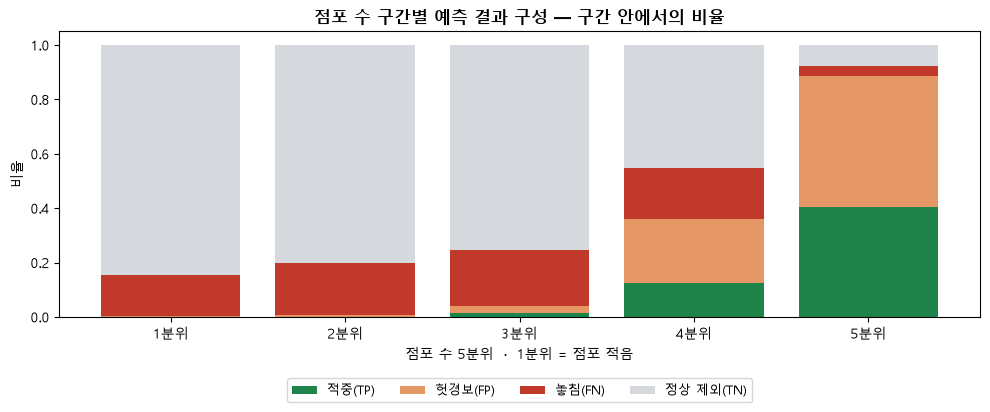

*그림 10*

읽는 법 — 같은 내용을 그림으로 본 것임. 초록이 적중, 주황이 헛경보, 붉은색이 놓침, 회색이 정상 제외임.


|  | 전체_점포_수 | 총_유동인구_수 | 위험점수 | 칸수 |
|---|---|---|---|---|
| 적중(TP) | 39.0 | 1498436.0 | 0.63 | 575 |
| 헛경보(FP) | 32.0 | 1421691.5 | 0.61 | 786 |
| 놓침(FN) | 10.0 | 853167.0 | 0.44 | 848 |
| 정상 제외(TN) | 8.0 | 813800.0 | 0.40 | 3270 |

*표 45*

읽는 법 — 네 갈래별 중앙값 프로필임. 놓친 칸의 점포 수가 적중 칸보다 작으면 「작아서 못 잡은 것」임.

기준 — 네 갈래별 중앙값 프로필. **놓친 칸의 점포 수가 적중 칸보다 작으면 「작아서 못 잡은 것」**으로 읽음.


### 해석

**이 표가 곧 이 모델의 사용 설명서이고, 결론은 두 갈래로 갈림.** **「다음 분기에 줄어들 상권을 다 찾아내는 모델」로는 성립하지 않음** — 실제 순감소 1,423칸 중 848칸을 놓치고, 위험으로 찍은 1,361칸의 절반이 넘는 786칸이 헛경보임. 전체 순위로 보면 Lift(향상도) 1.627 로 「점포 수」 규칙(1.645)과 사실상 같음. **반면 「먼저 볼 50~300곳을 골라주는 도구」로는 성립함** — 상위 50칸 정밀도 70.0%(기저율의 2.70배)이고 점포 수 규칙(38.0%)과 목록이 8%만 겹쳐 **서로 다른 상권을 지목함.** **특히 점포가 적은 상권에서는 대안이 없음** — 가장 작은 1분위에서 점포 수 규칙은 Lift(향상도) 0.981 로 무작위 아래인데 모델은 1.740 임. **「전수 판정기」로 쓰면 실패하고 「우선순위 선별기」로 쓰면 성립한다는 것이 이 절의 결론임.**

**놓친 칸의 성격이 16절의 「정체되어 있으나 변화 시 취약」 유형과 겹친다.** 점수 순위로 좁히는 방식으로는 잡히지 않는 자리이므로, 그 구간은 순위가 아니라 두 축(사건 확률 × 방향 확률)으로 따로 관리해야 함. 순위와 유형을 함께 써야 하는 이유가 오차 분해에서 다시 나옴.

**헛경보를 줄이는 방향은 규모가 큰 구간에서 찾아야 함.** 큰 상권은 개·폐업이 잦아 점수가 높게 나오지만 그중 상당수는 결국 줄지 않음. 이 구간에서는 점수 하나가 아니라 직전 분기 순감소 여부와 함께 보는 것이 낫다.



## 15  두 단계로 나눈 모형

**핵심 한 줄 — 순감소를 “① 다음 분기에 개·폐업이 일어나는가”와 “② 일어났다면 감소 방향인가”로 나누자, 상권 규모 효과가 대부분 1단계에 모여 있음을 확인했음.**

### 왜 이 분석을 했나

기존 라벨은 “사건 발생”과 “감소 방향”이 합쳐져 있어 큰 상권이 자동으로 위험해 보이는 문제가 있음.

### 핵심 결과

- 1단계는 P(개업 또는 폐업 사건), 2단계는 P(순감소 | 사건)를 예측함. 최종 순감소 확률은 두 값을 곱함.
- 실제 데이터에서도 P(사건)=0.5608, P(순감소|사건)=0.4543이고 두 값을 곱한 0.2548이 전체 순감소율 0.2548과 정확히 일치했음.
- 점포 수와의 상관은 사건 여부 +0.448이었지만, 사건이 발생한 뒤 감소 방향과는 −0.039로 거의 관계가 없었음.
- 검증 AP는 단일 모형 0.408, 2단계 0.411로 차이는 **+0.003**에 그쳤음. 1단계 사건모형 AP는 **0.815**였음.



| 항목 | 핵심 수치 / 의미 |
|---|---|
| 1단계 | P(사건) · 규모 영향 큼 |
| 2단계 | P(순감소 \| 사건) · 규모 영향 거의 없음 |
| 최종 확률 | 두 확률의 곱 |
| 검증 AP | 단일 0.408 → 2단계 0.411 |

*표 46*


|  | AP | ROC-AUC | 정밀도 | 재현율 | Lift |
|---|---|---|---|---|---|
| 단일 모형 (랜덤포레스트) | 0.408 | 0.676 | 0.401 | 0.401 | 1.584 |
| 2단계 모형 | 0.411 | 0.677 | 0.407 | 0.407 | 1.609 |

*표 47*

읽는 법 — 단일 모형과 2단계 모형을 같은 검증 분기에서 비교한 것임. 차이가 작다는 점이 핵심이고, 나누는 이유는 성능이 아니라 규모 편향의 분리임.

기준 — AP·Lift(향상도) 기준. **차이가 작다는 점이 핵심**이며, 나누는 실익은 성능이 아니라 규모 편향의 분리임.


### 해석

2단계 모형의 가장 큰 장점은 성능 향상보다 해석임. “큰 상권이라 사건이 자주 생기는 효과”와 “사건이 생겼을 때 실제로 감소 쪽으로 기우는 위험”을 분리할 수 있음.



## 16  두 확률로 나눈 상권 유형

**핵심 한 줄 — 최종 위험점수 하나로만 줄 세우지 않고 “변화가 자주 생기는가”와 “변하면 감소하는가”를 두 축으로 남기면 성격이 다른 네 유형을 구분할 수 있음.**

### 왜 이 분석을 했나

**두 축의 이름부터 정리함.** **「사건」은 다음 분기에 개업이나 폐업이 일어날 확률**이고, **「방향」은 그 변화가 일어났을 때 점포가 줄어드는 쪽일 확률**임. **사건은 「얼마나 자주 흔들리는가」, 방향은 「흔들릴 때 어느 쪽으로 기우는가」를 뜻하므로 서로 다른 것을 재는 축임.** 최종 위험도는 두 확률의 곱이라 한 줄로 세우면 이 구분이 사라짐 — 그래서 곱하지 않고 **두 축을 그대로 두고 네 칸으로 나눔.**

두 확률을 곱하면 점포가 많은 상권이 앞에 오기 쉬움. 그러면 규모는 작지만 변화가 생겼을 때 취약한 상권이 뒤로 밀려남.

### 핵심 결과

- 검증 분기 중앙값을 기준으로 **사건확률 0.4390 · 순감소 조건부확률 0.5098**에서 네 유형을 나눴음.
- **「안정적」 935개, 「정체되어 있으나 변화 시 취약」 1,813개, 「활발하게 변하나 성장·유지」 1,772개, 「활발하게 변하면서 쇠퇴」 959개**였음.
- 실제 순감소율은 각각 **14.8% · 18.3% · 32.8% · 38.7%**로, 기저율 대비 **0.57 · 0.71 · 1.26 · 1.49배**였음.
- **골목상권에서는 「정체·취약형」이 41.1%로 가장 큰 비중**을 차지했고 그 유형의 평균 점포 수는 6.9개에 불과했음. 전통시장도 같은 유형이 40.9%로 최다였고, **발달상권과 관광특구는 「활발·성장/유지」가 41.2% · 48.3%로 최다**였음.



| 유형 | 두 축이 뜻하는 것 | 칸수 | 실제 순감소율 |
|---|---|---|---|
| 안정적 | **변화 자체가 드물고, 변화가 생겨도 줄어드는 쪽이 아님**(사건 낮음 · 방향 낮음) | 935 | 14.8% |
| 정체·취약 | **변화는 드물지만, 한번 생기면 줄어드는 쪽으로 기욺**(사건 낮음 · 방향 높음) | 1,813 | 18.3% |
| 활발·성장/유지 | **변화는 자주 생기지만, 생겨도 줄어들지는 않음**(사건 높음 · 방향 낮음) | 1,772 | 32.8% |
| 활발·쇠퇴 | **변화가 잦고, 생길 때마다 줄어드는 쪽으로 기욺**(사건 높음 · 방향 높음) | 959 | 38.7% |

*표 48*


|  |  | 칸수 | 실제순감소율 | 유형 | 기저율대비 |
|---|---|---|---|---|---|
| 사건_수준 | 방향_수준 | — | — | — | — |
| 낮음 | 낮음 | 935 | 0.148 | 안정적 | 0.57 |
| 낮음 | 높음 | 1813 | 0.183 | 정체되어 있으나 변화 시 취약 | 0.71 |
| 높음 | 낮음 | 1772 | 0.328 | 활발하게 변하나 성장·유지 | 1.26 |
| 높음 | 높음 | 959 | 0.387 | 활발하게 변하면서 쇠퇴 | 1.49 |

*표 49*

읽는 법 — 네 유형의 칸수와 실제 순감소율이며 마지막 열이 기저율 대비임. 이름 순서대로 순감소율이 오르면 두 축이 제 역할을 한 것임.

기준 — **「기저율대비」가 1.0 이면 전체 평균과 같음.** 이름 순서대로 실제 순감소율이 오르면 두 축이 제 역할을 한 것으로 판정함.


**두 축으로 나눈 네 유형** — 가로축은 「얼마나 자주 흔들리는가」(사건확률), 세로축은 「흔들릴 때 줄어드는 쪽인가」(방향확률). 경계는 검증 분기 중앙값(0.4390 · 0.5098).

| | 사건확률 낮음 | 사건확률 높음 |
|---|---|---|
| **방향확률 높음** | **정체되어 있으나 변화 시 취약** — 1,813칸 · 순감소 18.3% · 평균 6.9개 | **활발하게 변하면서 쇠퇴** — 959칸 · 순감소 38.7% · 평균 30.9개 |
| **방향확률 낮음** | **안정적** — 935칸 · 순감소 14.8% · 평균 7.8개 | **활발하게 변하나 성장·유지** — 1,772칸 · 순감소 32.8% · 평균 38.1개 |


### 해석

**정책적으로는 오른쪽 위 「활발·쇠퇴형」을 즉시 점검하고, 왼쪽 위 「정체·취약형」은 별도 관찰목록으로 관리하는 방식이 가능함.** 같은 최종 위험점수라도 두 유형은 필요한 대응이 다름 — 앞쪽은 이미 빠져나가는 중이라 공백을 줄이는 일이고, 뒤쪽은 조용하다가 한번에 무너지는 자리라 미리 붙잡는 일임.

**두 축을 곱해 한 줄로 만들면 왼쪽 위가 보이지 않는 것이 이 절의 요점임.** 「정체·취약」은 1,813칸으로 네 유형 중 가장 많은데 평균 점포가 6.9개뿐이라 곱으로 세우면 뒤로 밀림. 그런데도 실제 순감소율이 18.3%로 「안정적」(14.8%)보다 높음. **오른쪽 두 칸이 위험 목록 상단을 차지하는 것은 평균 점포가 30~38개로 커서 개·폐업이 자주 일어나기 때문**이고, 그것은 위험이 아니라 사건이 일어날 크기임. **그래서 최종 위험도 한 줄과 두 축 유형을 함께 써야 함.**



## 17  무엇이 위험과 관련되어 있는가

**핵심 한 줄 — 단일 모델에서는 규모·밀도 변수가 기여도의 3분의 2를 차지했지만, 사건과 방향을 분리하자 규모 영향은 주로 1단계에 남고 2단계에서는 4분의 1로 줄었음.**

### 왜 이 분석을 했나

변수 중요도를 그대로 “원인”으로 읽으면 안 됨. SHAP은 모델이 예측할 때 어떤 변수를 얼마나 사용했는지를 보여주는 설명 도구다.

### 핵심 결과

- 단일 모형에서 규모·밀도 관련 변수의 SHAP 기여 비중은 **66.6%**였음.
- 1단계 사건모형에서는 규모·밀도 비중이 **70.4%**로 더 커졌음. 반면 2단계 「사건 발생 후 감소 방향」에서는 **25.9%**까지 낮아졌음.
- **2단계에서 규모 변수를 빼고 보면 외식물가지수(0.0213) · 한식 업종 여부(0.0154) · 외식지출전망(0.0150) · 당월 매출 건수(0.0092) · 호프·간이주점 여부(0.0083) · 점포당 매출(0.0063)이 상위였음.** 규모가 조건으로 걸리고 나면 **업종 구성과 매출·물가 계열이 남는다**는 뜻임.
- **그런데 상위 두 자리를 차지한 외식물가지수·외식지출전망은 전국 단위 지표라 같은 분기 안에서 모든 상권에 같은 값이 들어감.** 그래서 **SHAP 기여는 크게 잡히지만 상권 간 순위는 전혀 바꾸지 못함**(전체 기여 중 비중 2.2% · 2.7%, 단일 모형 순위 16위 · 12위). **「SHAP이 높다」와 「순위에 기여한다」가 다르다는 것을 보여주는 자리**이고, 그래서 이 두 변수는 테스트 분기 예측에서 실질적인 역할이 없음. **규모를 뺀 뒤 실제로 순위를 가르는 것은 업종 구성과 점포당 매출 계열임.**



| 항목 | 핵심 수치 / 의미 |
|---|---|
| 규모·밀도 기여 | 단일 66.6% |
| 1단계 P(사건) | 70.4% |
| 2단계 P(순감소\|사건) | 25.9% |
| 2단계 핵심 방향 | 업종 구성·점포당 매출 계열의 상대적 중요도 상승 |

*표 50*


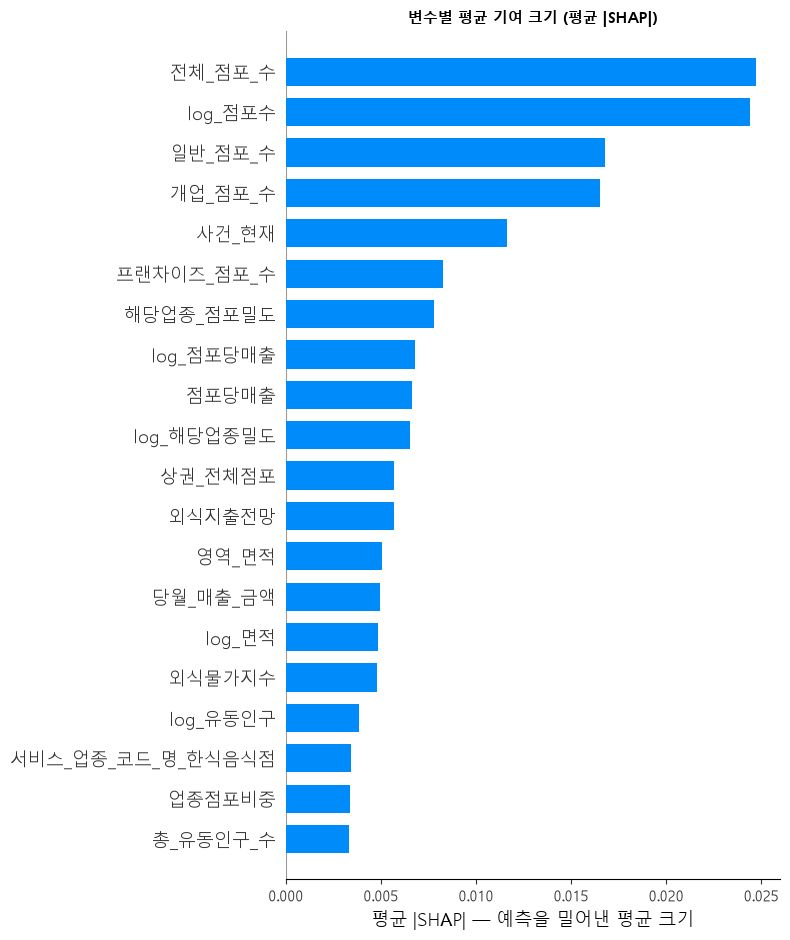

*그림 11*

읽는 법 — 단일 모형에서 각 변수가 예측을 밀어낸 「평균 크기」임. 방향은 알 수 없고 세기만 보여 줌. 맨 위 전체_점포_수 하나가 나머지를 압도함.


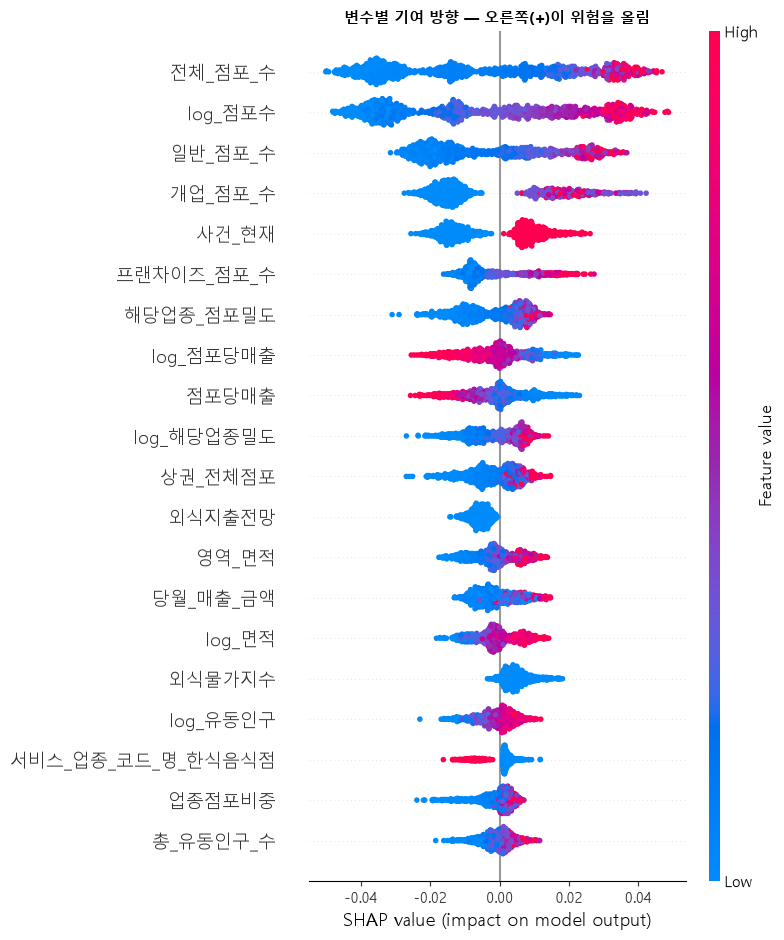

*그림 12*

읽는 법 — 같은 것을 방향까지 펼친 그림임. 점 하나가 칸 하나이고 오른쪽(+)이 위험을 올린 쪽임. 점 색이 붉을수록 그 변수의 값이 큼 — 즉 점포가 많을 때 오른쪽으로 몰리면 「크면 위험」이 읽힘.


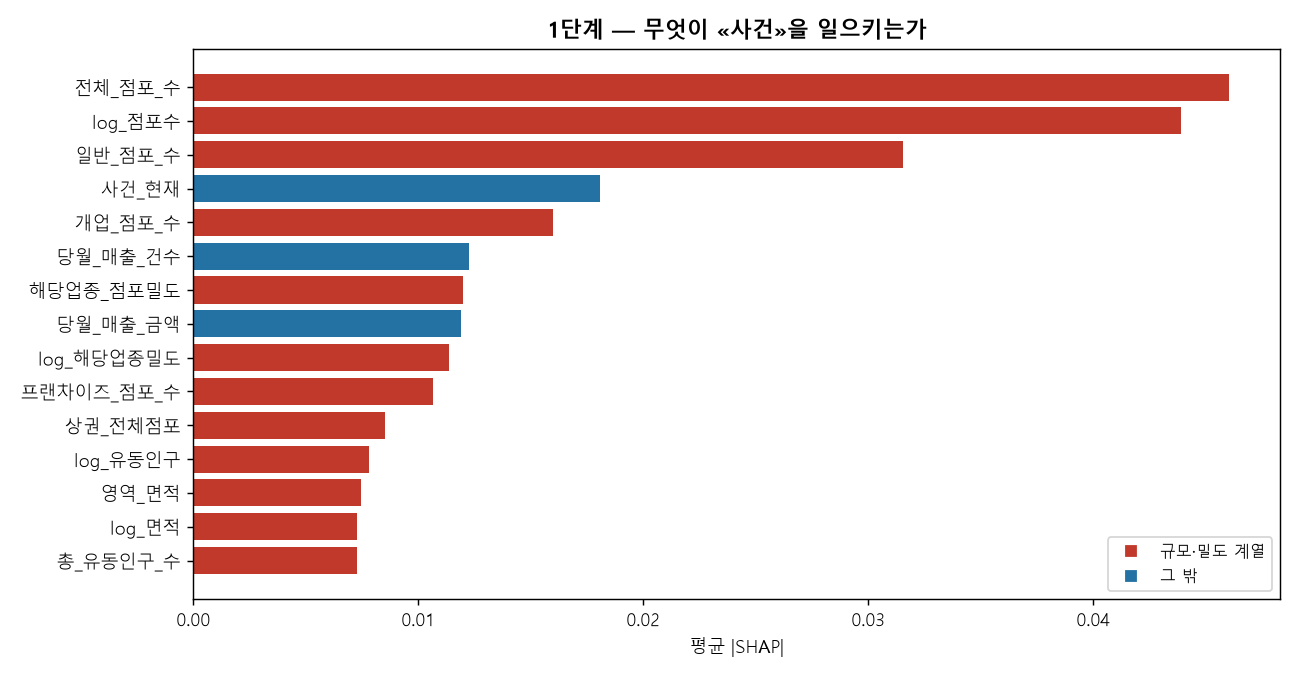

*그림 13*

읽는 법 — **1단계 — 기여의 크기.** 붉은 막대가 규모·밀도 계열임. **상위를 규모가 거의 다 차지함** — 개·폐업이 일어나는지 여부는 결국 칸의 크기가 결정한다는 뜻임.


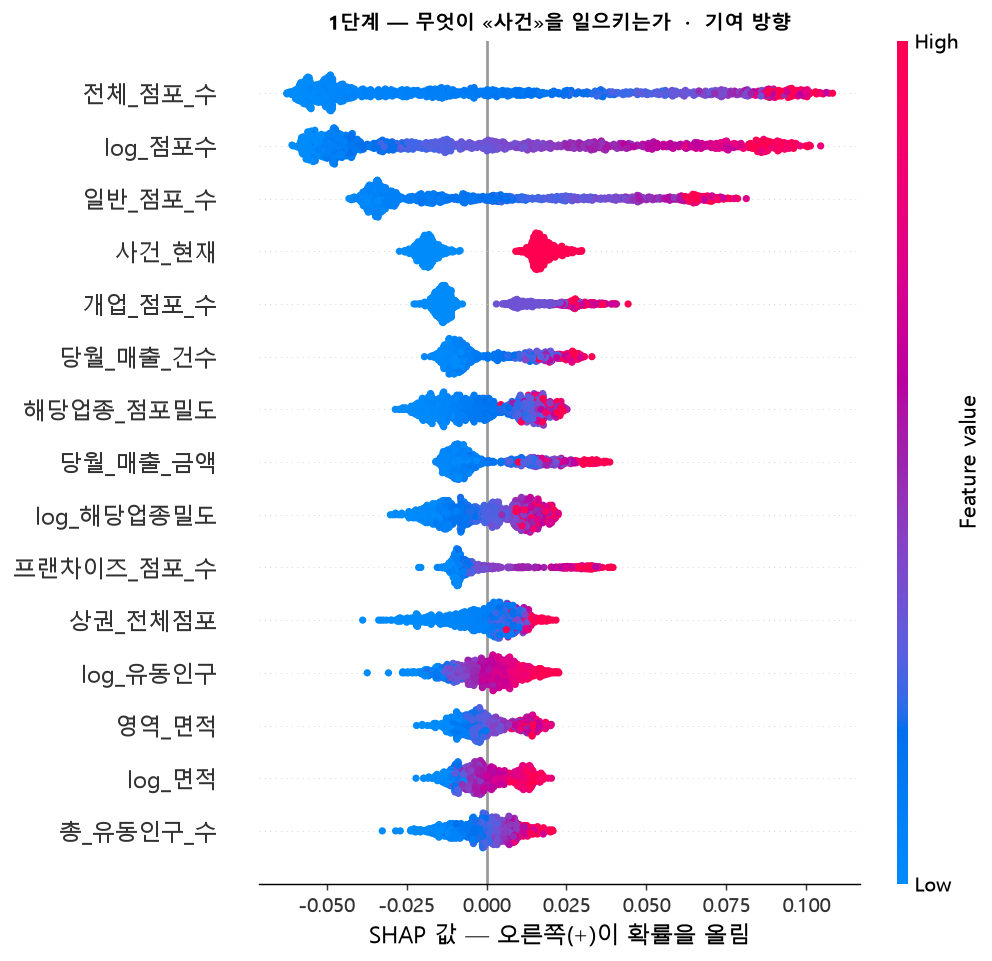

*그림 14*

읽는 법 — **1단계 — 기여의 방향.** 바로 위 막대를 방향까지 펼친 그림임. 점 하나가 칸 하나이고 오른쪽(+)이 사건 확률을 올린 쪽, 점 색이 붉을수록 그 변수의 값이 큼. **점포가 많은 칸(붉은 점)이 오른쪽으로 길게 뻗어 「크면 사건이 잦다」가 그대로 보임.**


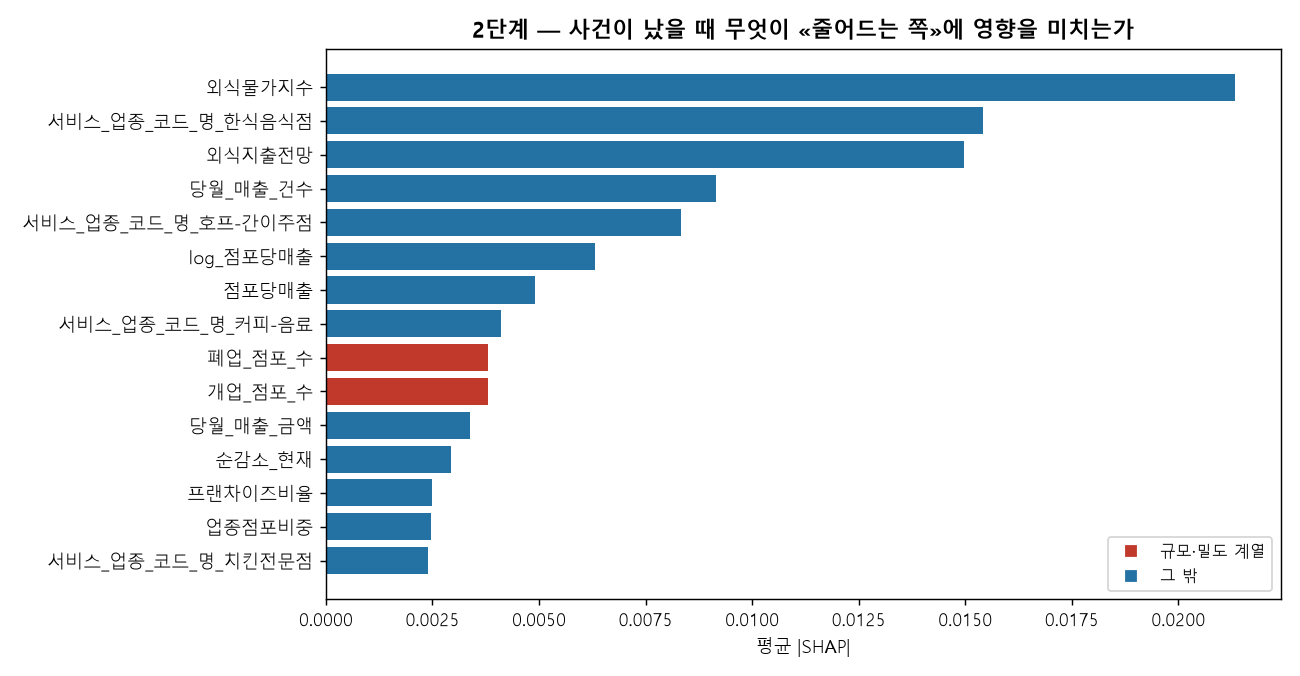

*그림 15*

읽는 법 — **2단계 — 기여의 크기.** 1단계와 같은 형식이라 나란히 비교됨. **붉은 막대가 상위에서 밀려나고 파란 막대가 올라온 것**이 이 절의 결과임 — 규모·밀도 비중이 70.4%에서 25.9%로 떨어짐.


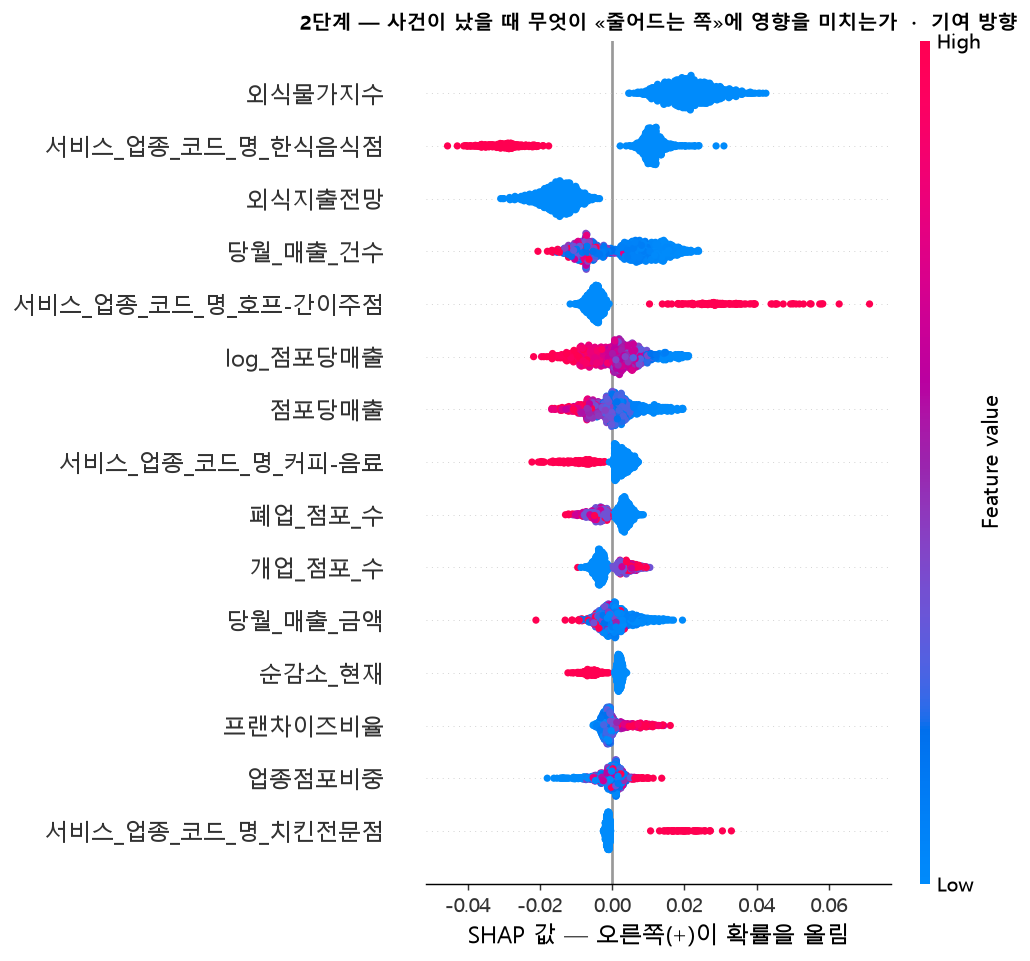

*그림 16*

읽는 법 — **2단계 — 기여의 방향.** 규모가 이미 조건으로 걸려 있으므로 **여기서 오른쪽으로 미는 변수가 「크기와 무관한 위험 요인」**임. 다만 상위의 외식물가지수·외식지출전망은 분기 안에서 모든 상권에 같은 값이라 상권 간 순위는 바꾸지 못함 — 실제로 순위를 가르는 것은 업종 구성과 점포당 매출 계열임.


### 해석

따라서 “위험을 만드는 원인”이라고 단정하기보다 “규모 효과를 분리한 뒤에도 모델이 위험 판단에 사용한 요인”이라고 표현하는 것이 정확하다. 인과효과를 말하려면 별도의 인과설계가 필요함.



## 18  위험도 공간 분석

**핵심 한 줄 — 지도에서는 위험등급이 높아질수록 실제 순감소율도 **13.4% → 42.1%**로 증가했음. 다만 자치구 경계나 역과의 거리 자체는 위험을 잘 설명하지 못했음.**

### 왜 이 분석을 했나

예측 결과가 실제 공간에서 어디에 모이는지 확인하고, 행정구역·역세권 같은 단순 입지 기준으로 대체할 수 있는지 점검했음.

### 핵심 결과

- 원본 좌표계는 EPSG:5181로 확인했고, 서울 안 5,479개 상권×업종 조합을 지도 분석에 사용했음.
- 위험점수 4분위로 나눈 실제 순감소율은 관찰 **13.4%** → 주의 **20.0%** → 경계 **28.3%** → 위험 **42.1%**로 단조 증가했음.
- 상권 경계 폴리곤이 없어 점·버블·500m 격자 등으로 분포를 표현했으며, 자치구 외곽선은 위치 확인용 근사치라 면적 계산에는 쓰지 않았음.
- 역 밖 0~250m, 250~500m, 500m~1km, 1km 초과 구간의 평균 위험이 **0.465 · 0.504 · 0.504 · 0.475로 사실상 평평했고 순서도 맞지 않았음.** 역세권 상권 자체만 평균 위험 0.627로 높은데, **그 상권들의 평균 점포가 52.4개로 역 밖(20.1~23.3개)의 2.4배**여서 거리 효과가 아니라 규모 효과로 읽힘.



| 항목 | 핵심 수치 / 의미 |
|---|---|
| 좌표계 | EPSG:5181 |
| 지도 표본 | 5,479개 |
| 위험등급 실제 순감소율 | 13.4% → 20.0% → 28.3% → 42.1% |
| 역 거리 효과 | 뚜렷한 거리 구배 없음 |

*표 51*


|  | 칸수 | 평균위험점수 | 실제순감소율 | 평균점포 | 기저율대비 |
|---|---|---|---|---|---|
| 관찰 | 1370 | 0.303 | **0.134** | 6.273 | 0.52 |
| 주의 | 1370 | 0.405 | 0.200 | 9.301 | 0.77 |
| 경계 | 1369 | 0.504 | 0.283 | 19.833 | 1.09 |
| 위험 | 1370 | 0.632 | **0.421** | 50.058 | 1.62 |

*표 52*

읽는 법 — 위험등급별 실제 순감소율이 단조 증가하는지 보는 표임. 증가하지 않으면 등급 경계를 다시 잡아야 함.

기준 — **위험등급이 오를 때 실제 순감소율이 단조 증가해야** 그 등급을 쓸 수 있음. 「기저율대비」 1.0 이 전체 평균임.


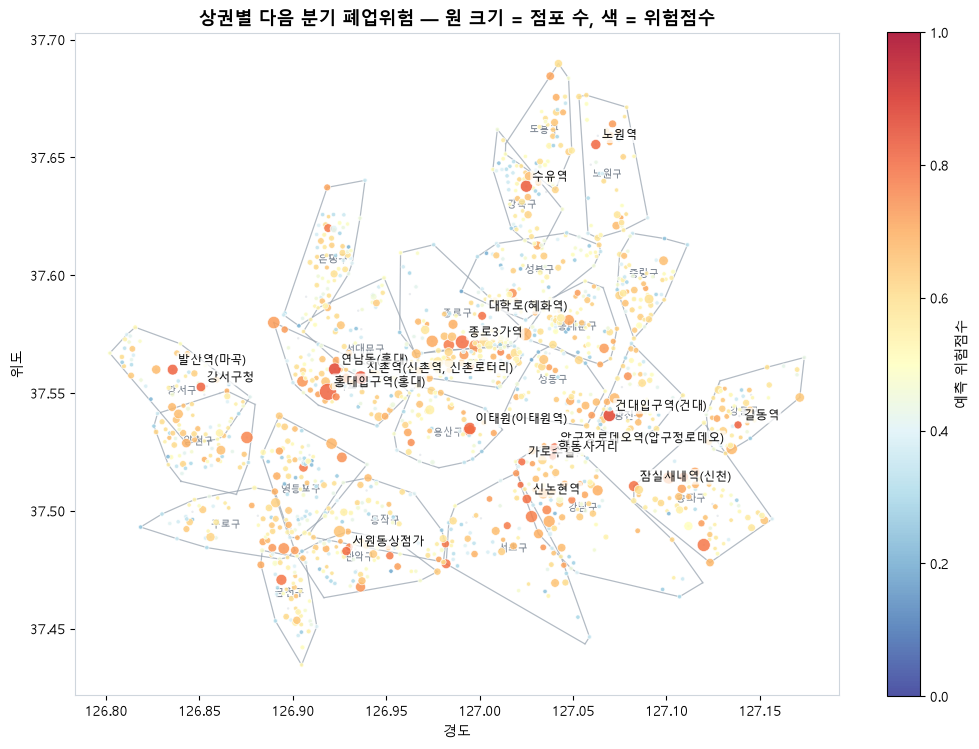

*그림 17*

읽는 법 — 상권마다 그 안에서 가장 위험한 업종을 골라 찍은 지도임. 원 크기가 점포 수, 색이 위험점수이고 상위 18곳에 상권명을 붙였음. 큰 원이 붉은 곳이 「크고 위험한 상권」임.


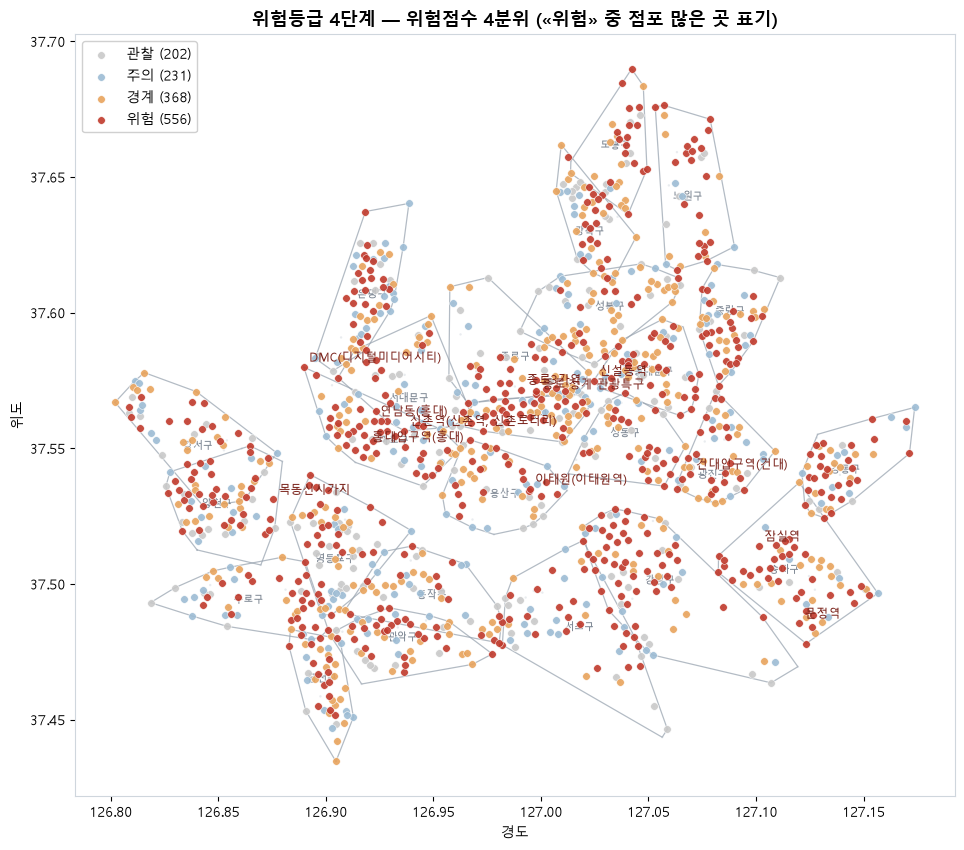

*그림 18*

읽는 법 — 같은 지도를 위험점수 4분위로 색만 바꾼 것임. 붉은 점(위험)이 도심·강남축에 몰리고, 같은 자치구 안에서도 색이 갈리는 것이 「대응 단위는 상권」이라는 근거임.


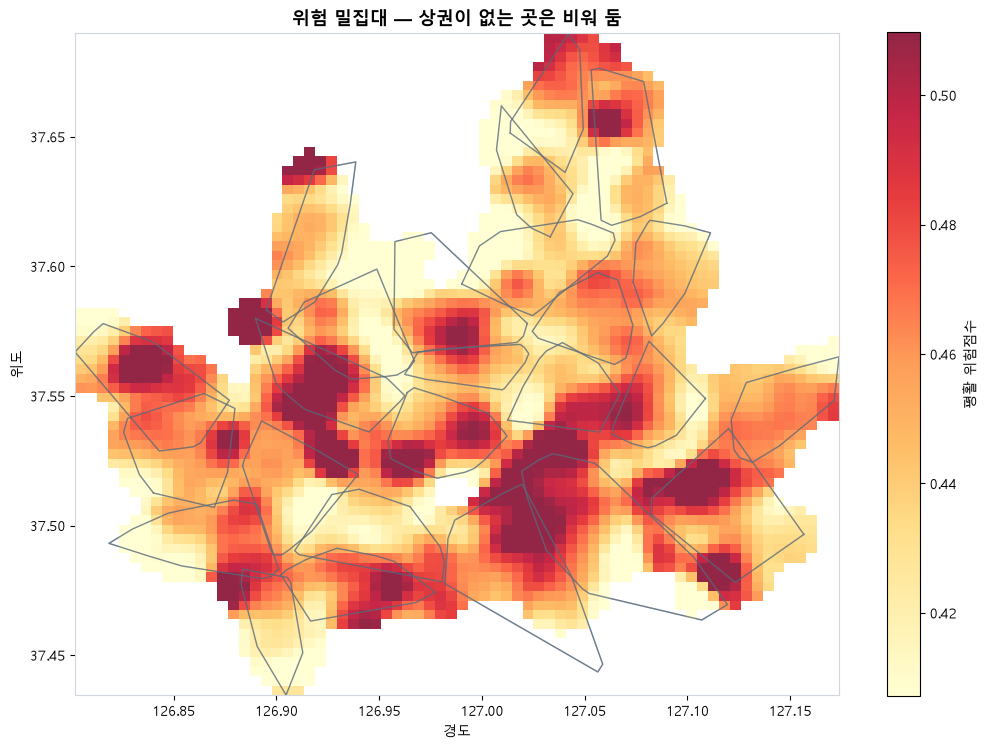

*그림 19*

읽는 법 — 점을 지우고 위험점수를 공간으로 평활한 지도임. 상권이 없는 곳은 비워 두었으므로 빈 곳은 「안전」이 아니라 「관측이 없음」임.


|  | 상권수 | 평균위험 | 실제순감소율 | 평균점포 |
|---|---|---|---|---|
| **역세권 상권** | **191** | **0.627** | **0.461** | **52.419** |
| 0~250m | 66 | 0.465 | 0.212 | 22.000 |
| 250~500m | 370 | 0.504 | 0.273 | 23.341 |
| 500m~1km | 519 | 0.504 | 0.289 | 23.306 |
| 1km 초과 | 211 | 0.475 | 0.280 | 20.137 |

*표 53*

읽는 법 — 역거리 구간별 평균 위험과 평균 점포임. 첫 줄(역세권 상권)만 점포 수가 두 배 이상 큼.

기준 — 거리 구간이 멀어질수록 위험이 단조 증가해야 「거리 효과」로 볼 수 있음. **평균 점포 수가 함께 움직이면 거리 효과가 아니라 규모 효과임.**


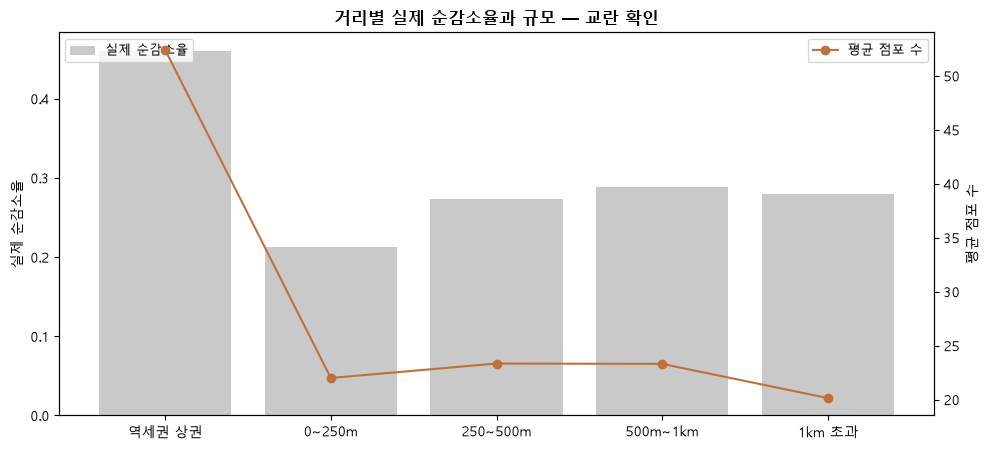

*그림 20*

읽는 법 — 회색 막대가 실제 순감소율, 주황 선이 평균 점포 수임. 두 줄이 같이 움직이면 거리 효과가 아니라 규모 효과라는 뜻임.


### 해석

지도는 “어느 상권을 먼저 볼 것인가”를 보여주는 도구로는 유용하지만, 자치구 전체가 위험하다고 해석하거나 정확한 면적 효과를 계산하는 데는 현재 자료가 부족함.



## 19  종합 결론

**핵심 한 줄 — 다음 분기 순감소를 완벽하게 예측한 것은 아니지만, 상위 소수 고위험 상권을 한 분기 먼저 선별하고 규모에 가려진 위험 구조를 분리해 설명할 수 있었음.**

### 왜 이 분석을 했나

이 연구의 결론은 “모델이 좋다/나쁘다” 한 줄이 아니라, 어디까지 예측할 수 있고 무엇을 통제해야 하며 실제 운영에서 어떻게 써야 하는지를 함께 제시하는 것임.

### 핵심 결과

- **Q1 예측 가능성**: 상위 100개 정밀도 62.0%로 전체 평균 26.0%의 2.39배였음. 다만 같은 100개는 **실제 순감소 1,423곳 중 62곳(재현율 4.4%)** 만 포착함. 위험순위 전체를 요약한 AP 는 0.413 으로 기저율 0.260 의 1.59배이고, 넓게 선정하면 점포 수 기준과 차이가 줄어듦. 따라서 「예측 가능함」는 **누락을 감수하고 소수를 우선 선별하는 조건에서만** 성립함.
- Q2 상권유형: 규모를 통제하기 전과 후의 결론이 달라졌음. 골목상권은 단순 비교 OR 0.813이었지만 규모 통제 후 공통 OR 1.061이었고, 규모별 효과도 서로 달랐다.
- **업종 효과**: 한식음식점은 단순 비교 +1.85%p에서 PSM 후 ATT −6.53%p로 부호가 뒤집혔음. 네 상권유형에서 모두 음수(골목 −5.39 · 전통시장 −8.51 · 발달 −9.30%p)이므로 한 유형의 산물이 아님. “업종 자체의 위험”처럼 보였던 상당 부분이 규모 차이였음.
- Q3 동일 업종의 입지 효과: 10개 중 8개 업종에서 상권유형 차이가 있었지만, 호프·간이주점처럼 큰 업종과 치킨전문점처럼 거의 없는 업종이 함께 존재했음.
- 2단계 모형: 규모 효과는 주로 “사건이 생기는가”에 몰려 있었고, “사건이 생긴 뒤 감소하는가”에서는 크게 줄었음.
- 정책 단위: 자치구보다 개별 상권이 적절하며, 상위 100~300개를 우선 점검 목록으로 사용하고 네 가지 상권 유형에 따라 관리 강도를 달리하는 방식이 타당하다.



| 항목 | 핵심 수치 / 의미 |
|---|---|
| 가장 실용적인 사용법 | 상위 100~300개 우선 점검 + 4유형 별도 관리 |
| 가장 중요한 통계 교훈 | 규모를 통제하지 않으면 상권유형·업종의 결론 방향이 반대로 나올 수 있음 |
| 기존 지표와 차이 | 서울시 HL 지표는 다음 분기 선별 Lift(향상도) 0.937로 낮아 목적이 다름 |
| 핵심 한계 | 테스트 1개 분기 · 사업자등록 말소 시차 · 카드매출 추정 · 상권 폴리곤 부재 |

*표 54*


### 해석

최종적으로 이 모델은 “전수 판정기”보다 “다음 분기에 먼저 확인할 상권을 좁혀주는 우선순위 선별 도구”로 보는 것이 맞음. 반대로 **누락을 줄이는 것이 목표라면 이 모델을 근거로 쓸 수 없다** — 재현율을 올리려면 넓게 찍어야 하고, 그 구간에서는 점포 수 순서와 결과가 수렴함.

**남은 한계 하나를 분명히 적어 둠 — 작동점 표본이 작음.** 상위 100칸의 정밀도 62.0%는 100개 표본에서 나온 값이라 ±4.9%p 정도 흔들릴 수 있음. **운영에 쓰기 전에 분기를 더 쌓아 이 값이 유지되는지 확인해야 함.**



## 20  비즈니스 제언

**핵심 한 줄 — 지원 대상은 업종이 아니라 상권 단위로, 그것도 「두 축」으로 골라야 함. 규모를 통제하지 않은 목록은 방향이 반대로 나옴.**

### 왜 이 분석을 했나

앞 절들의 결과는 그대로 두면 「누구에게 무엇을 하라」로 이어지지 않음. 각 결론이 어떤 실행으로 옮겨지는지, 그리고 하지 말아야 할 것이 무엇인지를 함께 적었음.

### 핵심 결과

- **경보 규모는 상위 100~300칸으로 운영함.** 검증에서 정밀도가 가장 높은 지점은 상위 50칸이지만 그 규모로는 실제 순감소의 2.5%만 잡으므로, **점검 인력이 감당할 수 있는 범위까지 넓힌 값임.** 상위 100칸의 정밀도가 0.620(기저율의 2.39배)이고, 상위 500칸을 넘기면 점포 수 순 목록과 57.2%가 겹쳐 모델을 쓸 이유가 사라짐.
- **대상 선정은 최종 위험도 한 줄이 아니라 두 축으로 함.** 곱으로 줄 세우면 점포가 많은 상권이 앞에 오고, 「정체되어 있으나 변화 시 취약」(골목상권의 41.1%)이 뒤로 밀려 보이지 않음.
- **소규모 상권 지원에 먼저 적용함.** 가장 작은 규모 구간에서 점포 수 규칙은 Lift(향상도) 0.981로 무작위 아래인데 모델은 1.740임. 크기로는 못 찾는 곳을 찾는 것이 이 모델의 값임.
- **업종을 기준으로 지원을 설계하지 않음.** 규모·유동인구·면적·집객시설을 맞추면 한식음식점은 오히려 6.53%p 안전한 쪽으로 뒤집힌다(네 유형 모두 같은 방향). 「이 업종이 위험하다」는 목록은 규모 교란의 산물임.
- **입지 처방은 업종별로 나눈다.** 호프-간이주점은 상권유형 효과가 ε²=0.1202로 크지만 치킨전문점은 0.0002로 사실상 0임. 전자는 입지 조정이, 후자는 입지와 무관한 지원이 맞음.
- **서울시 상권변화지표만으로 대상을 고르지 않음.** 「상권축소(HL)」 진단의 Lift(향상도)는 0.937~0.956으로 무작위보다 낮음. 이 지표는 지금까지의 상태 요약이고 다음 분기를 겨냥하지 않음.
- **행정 경계로 예산을 나누지 않음.** 같은 자치구 안에서도 상권마다 위험등급이 갈린다. 자치구는 집행 창구로만 쓰고 대상 선정은 상권 단위로 함.



| 제언 | 근거 절 | 실행 단위 |
|---|---|---|
| 상위 100~300칸으로 경보 규모를 고정 | 12절 · 13절 | 분기별 위험 목록 |
| 최종 위험도 대신 두 축(4유형)으로 대상 선정 | 16절 | 상권 × 업종 |
| 소규모 상권 지원에 우선 적용 | 6절 · 12절 | 점포 수 1~2분위 |
| 업종 기준 지원 설계 배제 | 9절 | 정책 설계 |
| 입지 처방을 업종별로 분리 | 8절 | 업종별 프로그램 |
| 상권변화지표 단독 사용 배제 | 5절 | 대상 선정 기준 |
| 자치구는 집행 창구, 선정은 상권 단위 | 18절 | 예산 배분 |

*표 55*


### 해석

네 유형은 서로 다른 처방을 요구함. **「활발하게 변하면서 쇠퇴」**(실제 순감소율 38.7%)는 이미 빠져나가는 중이므로 폐업 후 공백을 줄이는 쪽 — 임대 중개·업종 전환 상담이 맞고, **「정체되어 있으나 변화 시 취약」**(18.3%)은 평소 조용해서 지표에 걸리지 않으므로 한 곳이 빠질 때 연쇄가 일어나지 않도록 미리 붙잡는 쪽 — 임대료 안정·집객 보강이 맞음. **「활발하나 성장·유지」**(32.8%)는 회전이 빠른 것이 정상이므로 개입하지 않고, **「안정적」**(14.8%)은 관찰만 함.

운영 절차도 함께 정해 두어야 함. 작동점(상위 몇 칸)은 **검증 분기에서 정하고 테스트에 옮기는 규칙**을 지켜야 하며, 분기마다 목록을 새로 뽑되 **직전 분기 목록과의 겹침**을 함께 보고해야 함. 겹침이 갑자기 커지면 모델이 규모를 배우기 시작했다는 신호다.

마지막으로 이 분석이 답하지 못한 것을 명시해 둔다. **상권 경계 폴리곤**이 없어 면 단위 지도를 그릴 수 없고, **테스트가 한 분기**이므로 분기를 늘려 재확인해야 함. 「큰 골목상권이 왜 다른 유형처럼 움직이는가」도 열려 있음. 이 셋은 다음 분석의 과제다.

